# 12 — OpenCV Feature Similarity

This notebook computes CLIP and DINOv2 feature-space similarity for the complete OpenCV Telea restoration branch.

Feature similarity is evaluated only on image-like spatial regions:

- full image;
- painting content region;
- mask bounding-box crop for non-zero masks.

Sparse unordered mask-only pixels are intentionally excluded because CLIP and DINOv2 expect coherent image patches.

For each applicable region, the notebook compares:

- clean reference versus damaged/degraded input;
- clean reference versus OpenCV-restored output;
- improvement, defined as `restored_similarity - damaged_similarity`.

Positive feature-similarity improvement means the restored output is closer to the clean reference in CLIP/DINOv2 feature space than the damaged input.

In [1]:
from pathlib import Path


def find_project_root(
    start_path: Path,
) -> Path:
    """Find the repository root from a notebook or working directory."""
    start_path = start_path.resolve()

    candidate_paths = [
        start_path,
        *start_path.parents,
    ]

    root_markers = (
        ".git",
        "src",
        "config",
        "notebooks",
    )

    for candidate_path in candidate_paths:
        marker_count = sum(
            (candidate_path / marker_name).exists()
            for marker_name in root_markers
        )

        if marker_count >= 3:
            return candidate_path

    raise FileNotFoundError(
        f"Could not locate the project root from {start_path}."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
from __future__ import annotations

import json
import platform
import sys
from datetime import datetime, timezone
from hashlib import sha256
from pathlib import Path
from time import perf_counter
from typing import Any

import numpy as np
import pandas as pd
import PIL
from PIL import Image

try:
    from IPython.display import display
except ImportError:
    def display(value: Any) -> None:
        print(value)


SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


from restoration_eval import metrics_feature_similarity
from restoration_eval.metrics_feature_similarity import (
    DEFAULT_CLIP_MODEL_NAME,
    DEFAULT_CLIP_MODEL_REVISION,
    DEFAULT_DINOV2_MODEL_NAME,
    DEFAULT_DINOV2_MODEL_REVISION,
    DEFAULT_FEATURE_INPUT_SIZE,
    DEFAULT_MASK_BBOX_MARGIN,
    DEFAULT_MASK_BINARY_THRESHOLD,
    FEATURE_SIMILARITY_EVALUATION_REGIONS,
    FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
    FEATURE_SIMILARITY_MODULE_NAME,
    compute_feature_similarity_for_restorations,
    expected_feature_similarity_region_counts_from_metadata,
    expected_feature_similarity_rows_from_metadata,
    get_device,
    load_clip_model_and_processor,
    load_dinov2_model,
    rank_feature_similarity_cases,
    summarize_feature_similarity_metrics,
    validate_feature_similarity_metrics,
    validate_feature_similarity_runtime_dependencies,
)


required_feature_module_exports = [
    "compute_feature_similarity_for_restorations",
    "expected_feature_similarity_rows_from_metadata",
    "expected_feature_similarity_region_counts_from_metadata",
    "validate_feature_similarity_metrics",
    "summarize_feature_similarity_metrics",
    "rank_feature_similarity_cases",
    "validate_feature_similarity_runtime_dependencies",
]

missing_feature_module_exports = [
    export_name
    for export_name in required_feature_module_exports
    if not hasattr(metrics_feature_similarity, export_name)
]

if missing_feature_module_exports:
    raise RuntimeError(
        "Feature-similarity helper is missing required exports: "
        f"{missing_feature_module_exports}"
    )

print(
    "Feature-similarity helper loaded:",
    FEATURE_SIMILARITY_MODULE_NAME,
)

print(
    "Schema version:",
    FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
)

Feature-similarity helper loaded: restoration_eval.metrics_feature_similarity
Schema version: 2.0.0


In [3]:
# Canonical Notebook 12 configuration

NOTEBOOK_NAME = "12_opencv_feature_similarity"

MODEL_NAME = "opencv_telea"

TARGET_SIZE = 768

MASK_BINARY_THRESHOLD = DEFAULT_MASK_BINARY_THRESHOLD

MASK_BBOX_MARGIN = DEFAULT_MASK_BBOX_MARGIN

FEATURE_INPUT_SIZE = DEFAULT_FEATURE_INPUT_SIZE

CLIP_MODEL_NAME = DEFAULT_CLIP_MODEL_NAME

CLIP_MODEL_REVISION = DEFAULT_CLIP_MODEL_REVISION

DINOV2_MODEL_NAME = DEFAULT_DINOV2_MODEL_NAME

DINOV2_MODEL_REVISION = DEFAULT_DINOV2_MODEL_REVISION

PROGRESS_EVERY = 25

FEATURE_SCHEMA_VERSION = FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION

FEATURE_IMPLEMENTATION_NAME = FEATURE_SIMILARITY_MODULE_NAME


REQUIRED_DATASETS = (
    "canonical",
    "damage_size",
)

OPTIONAL_DATASETS = (
    "mask_robustness",
    "synthetic_degradation",
)

SUPPORTED_DATASETS = (
    *REQUIRED_DATASETS,
    *OPTIONAL_DATASETS,
)


DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DIR = DATA_DIR / "processed"

METADATA_DIR = PROCESSED_DIR / "metadata"

PROCESSED_METRICS_DIR = PROCESSED_DIR / "metrics"


RESTORATION_METADATA_PATH = (
    METADATA_DIR / "metadata_restored_opencv_telea.csv"
)

CLEAN_METADATA_PATH = (
    METADATA_DIR / "metadata_processed_clean.csv"
)

LPIPS_METRICS_PATH = (
    PROCESSED_METRICS_DIR / "metrics_opencv_telea_lpips.csv"
)

CLASSICAL_METRICS_PATH = (
    PROCESSED_METRICS_DIR / "metrics_opencv_telea_classical.csv"
)

FEATURE_OUTPUT_PATH = (
    PROCESSED_METRICS_DIR / "metrics_opencv_telea_feature_similarity.csv"
)


OUTPUTS_DIR = PROJECT_ROOT / "outputs"

NOTEBOOK_OUTPUT_DIR = (
    OUTPUTS_DIR / "12_opencv_feature_similarity"
)

FIGURE_DIR = (
    OUTPUTS_DIR / "figures" / "opencv_feature_similarity"
)

AUDIT_OUTPUT_PATH = (
    NOTEBOOK_OUTPUT_DIR / "opencv_feature_similarity_audit.csv"
)


feature_dependency_check_df = (
    validate_feature_similarity_runtime_dependencies()
)

FEATURE_RUNTIME_READY = bool(
    feature_dependency_check_df["passed"].astype(bool).all()
)


print(
    "Notebook:",
    NOTEBOOK_NAME,
)

print(
    "Evaluation regions:",
    ", ".join(FEATURE_SIMILARITY_EVALUATION_REGIONS),
)

print(
    "Feature runtime ready:",
    FEATURE_RUNTIME_READY,
)

Notebook: 12_opencv_feature_similarity
Evaluation regions: full_image, content_region, mask_bbox_crop
Feature runtime ready: True


In [4]:
def resolve_project_path(
    path_value: Any,
) -> Path:
    """Resolve a project-relative or absolute path."""
    if path_value is None:
        raise ValueError(
            "Path value is None."
        )

    try:
        if pd.isna(path_value):
            raise ValueError(
                "Path value is null."
            )
    except TypeError:
        pass

    path_text = str(path_value).strip()

    if not path_text:
        raise ValueError(
            "Path value is blank."
        )

    path = Path(path_text)

    if path.is_absolute():
        return path.resolve()

    return (PROJECT_ROOT / path).resolve()


def project_relative_path(
    path_value: Any,
) -> str:
    """Return a portable project-relative path where possible."""
    path = resolve_project_path(path_value)

    try:
        return path.relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()


def file_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """Calculate a SHA-256 checksum."""
    digest = sha256()

    with Path(file_path).open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(chunk_size), b""):
            digest.update(chunk)

    return digest.hexdigest()


def build_check(
    check_name: str,
    observed: Any,
    expected: Any,
    passed: bool,
) -> dict[str, Any]:
    """Build a compact validation-check row."""
    return {
        "check": check_name,
        "observed": observed,
        "expected": expected,
        "passed": bool(passed),
    }

In [5]:
# Validate canonical Notebook 12 inputs

required_input_paths = {
    "notebook_08_restoration_metadata": RESTORATION_METADATA_PATH,
    "clean_preprocessing_metadata": CLEAN_METADATA_PATH,
}

optional_input_paths = {
    "notebook_11_lpips_metrics": LPIPS_METRICS_PATH,
    "notebook_09_classical_metrics": CLASSICAL_METRICS_PATH,
}


input_inventory_df = pd.DataFrame(
    [
        {
            "input_name": input_name,
            "required": True,
            "input_path": project_relative_path(input_path),
            "exists": input_path.is_file(),
            "file_size_bytes": (
                input_path.stat().st_size
                if input_path.is_file()
                else 0
            ),
        }
        for input_name, input_path in required_input_paths.items()
    ]
    + [
        {
            "input_name": input_name,
            "required": False,
            "input_path": project_relative_path(input_path),
            "exists": input_path.is_file(),
            "file_size_bytes": (
                input_path.stat().st_size
                if input_path.is_file()
                else 0
            ),
        }
        for input_name, input_path in optional_input_paths.items()
    ]
)

display(
    input_inventory_df
)


missing_required_input_df = input_inventory_df.loc[
    input_inventory_df["required"].astype(bool)
    & ~input_inventory_df["exists"].astype(bool),
    [
        "input_name",
        "input_path",
    ],
].copy()


empty_required_input_df = input_inventory_df.loc[
    input_inventory_df["required"].astype(bool)
    & input_inventory_df["exists"].astype(bool)
    & input_inventory_df["file_size_bytes"].eq(0),
    [
        "input_name",
        "input_path",
    ],
].copy()


input_inventory_checks_df = pd.DataFrame(
    [
        build_check(
            "required_inputs_exist",
            missing_required_input_df["input_name"].tolist(),
            [],
            missing_required_input_df.empty,
        ),
        build_check(
            "required_inputs_non_empty",
            empty_required_input_df["input_name"].tolist(),
            [],
            empty_required_input_df.empty,
        ),
    ]
)

display(
    input_inventory_checks_df
)

display(
    feature_dependency_check_df
)

if not input_inventory_checks_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 12 required input validation failed."
    )

,input_name,required,input_path,exists,file_size_bytes
0,notebook_08_restoration_metadata,True,data/processed/metadata/metadata_restored_open...,True,762016
1,clean_preprocessing_metadata,True,data/processed/metadata/metadata_processed_cle...,True,30443
2,notebook_11_lpips_metrics,False,data/processed/metrics/metrics_opencv_telea_lp...,True,845169
3,notebook_09_classical_metrics,False,data/processed/metrics/metrics_opencv_telea_cl...,True,1690289


,check,observed,expected,passed
0,required_inputs_exist,[],[],True
1,required_inputs_non_empty,[],[],True


,component,module,version,required,installed,passed
0,torch,torch,2.5.1+cu121,True,True,True
1,torchvision,torchvision,0.20.1+cu121,True,True,True
2,transformers,transformers,4.48.3,True,True,True
3,safetensors,safetensors,0.8.0,True,True,True
4,Pillow,PIL,9.5.0,True,True,True


In [6]:
# Load Notebook 12 metadata inputs

restoration_metadata_raw_df = pd.read_csv(
    RESTORATION_METADATA_PATH
)

clean_metadata_df = pd.read_csv(
    CLEAN_METADATA_PATH
)

print(
    "Raw restoration metadata rows:",
    len(restoration_metadata_raw_df),
)

print(
    "Clean metadata rows:",
    len(clean_metadata_df),
)

display(
    restoration_metadata_raw_df.head()
)

display(
    clean_metadata_df.head()
)

Raw restoration metadata rows: 410
Clean metadata rows: 50


,restoration_case_id,model_name,algorithm,inpaint_radius,opencv_version,restoration_generator_name,restoration_generator_version,execution_device,execution_backend,operating_system,...,mean_absolute_difference_effect,maximum_absolute_difference,effect_mask_filename,effect_mask_path,degraded_filename,degraded_path,effect_mask_sha256,degraded_sha256,effect_mask_file_size_bytes,degraded_file_size_bytes
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,opencv_telea__canonical__canonical__p001_mixed...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,opencv_telea__canonical__canonical__p001_scrat...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0,cpu,opencv_cpu,Windows-11-10.0.26200-SP0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


In [7]:
# Filter to the OpenCV Telea rows that are valid metric inputs

restoration_metadata_df = restoration_metadata_raw_df.copy()

if "status" in restoration_metadata_df.columns:
    restoration_metadata_df = (
        restoration_metadata_df
        .loc[restoration_metadata_df["status"].astype(str).eq("ok")]
        .copy()
    )

if "model_name" in restoration_metadata_df.columns:
    restoration_metadata_df = (
        restoration_metadata_df
        .loc[restoration_metadata_df["model_name"].astype(str).eq(MODEL_NAME)]
        .copy()
    )

if "dataset_name" not in restoration_metadata_df.columns:
    restoration_metadata_df["dataset_name"] = "canonical"

restoration_metadata_df = (
    restoration_metadata_df
    .loc[restoration_metadata_df["dataset_name"].isin(SUPPORTED_DATASETS)]
    .copy()
)

dataset_inventory_df = (
    restoration_metadata_df
    .groupby("dataset_name", dropna=False)
    .agg(
        rows=("case_id", "count"),
        paintings=("painting_id", "nunique"),
    )
    .reset_index()
    .sort_values("dataset_name")
)

required_dataset_check_df = pd.DataFrame(
    [
        build_check(
            f"required_dataset_present__{dataset_name}",
            int(restoration_metadata_df["dataset_name"].eq(dataset_name).sum()),
            "> 0",
            bool(restoration_metadata_df["dataset_name"].eq(dataset_name).any()),
        )
        for dataset_name in REQUIRED_DATASETS
    ]
)

display(
    dataset_inventory_df
)

display(
    required_dataset_check_df
)

if restoration_metadata_df.empty:
    raise RuntimeError(
        "No OpenCV Telea restoration rows available for Notebook 12."
    )

if not required_dataset_check_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 12 required dataset check failed."
    )

,dataset_name,rows,paintings
0,canonical,250,50
1,damage_size,35,5
2,mask_robustness,75,5
3,synthetic_degradation,50,5


,check,observed,expected,passed
0,required_dataset_present__canonical,250,> 0,True
1,required_dataset_present__damage_size,35,> 0,True


In [8]:
# Standardize paths to absolute filesystem paths for helper execution

required_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_path_columns = [
    column
    for column in required_path_columns
    if column not in restoration_metadata_df.columns
]

if missing_path_columns:
    raise RuntimeError(
        f"Restoration metadata missing required path columns: {missing_path_columns}"
    )


for column in required_path_columns:
    restoration_metadata_df[column] = restoration_metadata_df[column].map(
        lambda value: resolve_project_path(value).as_posix()
    )


path_validation_records = []

for column in required_path_columns:
    exists_series = restoration_metadata_df[column].map(
        lambda value: Path(value).is_file()
    )

    non_empty_series = restoration_metadata_df[column].map(
        lambda value: Path(value).is_file() and Path(value).stat().st_size > 0
    )

    path_validation_records.append(
        build_check(
            f"{column}_files_exist",
            int(exists_series.sum()),
            len(restoration_metadata_df),
            bool(exists_series.all()),
        )
    )

    path_validation_records.append(
        build_check(
            f"{column}_files_non_empty",
            int(non_empty_series.sum()),
            len(restoration_metadata_df),
            bool(non_empty_series.all()),
        )
    )


path_validation_df = pd.DataFrame(
    path_validation_records
)

display(
    path_validation_df
)

if not path_validation_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 12 path validation failed."
    )

,check,observed,expected,passed
0,clean_path_files_exist,410,410,True
1,clean_path_files_non_empty,410,410,True
2,damaged_path_files_exist,410,410,True
3,damaged_path_files_non_empty,410,410,True
4,restored_path_files_exist,410,410,True
5,restored_path_files_non_empty,410,410,True
6,mask_path_files_exist,410,410,True
7,mask_path_files_non_empty,410,410,True


In [9]:
# Repair/validate content-region coordinates row-wise from clean metadata

content_region_columns = [
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

clean_content_lookup_df = (
    clean_metadata_df[
        [
            "painting_id",
            *content_region_columns,
        ]
    ]
    .drop_duplicates(
        subset=["painting_id"],
        keep="first",
    )
    .set_index("painting_id")
)

for column in content_region_columns:
    if column not in restoration_metadata_df.columns:
        restoration_metadata_df[column] = np.nan

    fill_values = restoration_metadata_df["painting_id"].map(
        clean_content_lookup_df[column]
    )

    restoration_metadata_df[column] = restoration_metadata_df[column].where(
        restoration_metadata_df[column].notna(),
        fill_values,
    )

    restoration_metadata_df[column] = pd.to_numeric(
        restoration_metadata_df[column],
        errors="coerce",
    )


content_region_valid_series = (
    restoration_metadata_df[content_region_columns]
    .notna()
    .all(axis=1)
    & np.isfinite(restoration_metadata_df[content_region_columns]).all(axis=1)
    & restoration_metadata_df["content_x_max"].gt(restoration_metadata_df["content_x_min"])
    & restoration_metadata_df["content_y_max"].gt(restoration_metadata_df["content_y_min"])
)

content_region_check_df = pd.DataFrame(
    [
        build_check(
            "content_region_coordinates_valid",
            int(content_region_valid_series.sum()),
            len(restoration_metadata_df),
            bool(content_region_valid_series.all()),
        )
    ]
)

display(
    content_region_check_df
)

if not content_region_valid_series.all():
    display(
        restoration_metadata_df.loc[
            ~content_region_valid_series,
            [
                "case_id",
                "dataset_name",
                "painting_id",
                *content_region_columns,
            ],
        ].head(30)
    )

    raise RuntimeError(
        "Notebook 12 content-region coordinate validation failed."
    )

,check,observed,expected,passed
0,content_region_coordinates_valid,410,410,True


In [10]:
# Add canonical metric IDs and mask metadata used by the feature helper

if "restoration_case_id" not in restoration_metadata_df.columns:
    restoration_metadata_df["restoration_case_id"] = (
        restoration_metadata_df["dataset_name"].astype(str)
        + "__"
        + restoration_metadata_df["case_id"].astype(str)
        + "__"
        + MODEL_NAME
    )

restoration_metadata_df["metric_case_id"] = (
    restoration_metadata_df["restoration_case_id"].astype(str)
)

if "mask_type" in restoration_metadata_df.columns:
    restoration_metadata_df["metric_mask_type"] = restoration_metadata_df["mask_type"].astype(str)
elif "source_mask_semantics" in restoration_metadata_df.columns:
    restoration_metadata_df["metric_mask_type"] = restoration_metadata_df["source_mask_semantics"].astype(str)
else:
    restoration_metadata_df["metric_mask_type"] = "unknown"

if "mask_id" in restoration_metadata_df.columns:
    restoration_metadata_df["metric_mask_id"] = restoration_metadata_df["mask_id"].astype(str)
else:
    restoration_metadata_df["metric_mask_id"] = (
        restoration_metadata_df["metric_case_id"].astype(str)
        + "__mask"
    )

restoration_metadata_df["metric_applicability"] = "primary"


duplicate_metric_case_id_count = int(
    restoration_metadata_df["metric_case_id"].duplicated().sum()
)

metric_case_id_check_df = pd.DataFrame(
    [
        build_check(
            "metric_case_ids_unique",
            duplicate_metric_case_id_count,
            0,
            duplicate_metric_case_id_count == 0,
        )
    ]
)

display(
    metric_case_id_check_df
)

if duplicate_metric_case_id_count:
    display(
        restoration_metadata_df.loc[
            restoration_metadata_df["metric_case_id"].duplicated(keep=False),
            [
                "dataset_name",
                "case_id",
                "restoration_case_id",
                "metric_case_id",
            ],
        ].head(30)
    )

    raise RuntimeError(
        "Notebook 12 metric_case_id uniqueness check failed."
    )

,check,observed,expected,passed
0,metric_case_ids_unique,0,0,True


In [11]:
# Compute actual mask-area inventory for zero-control handling and expected row counts

mask_inventory_records = []

for row in restoration_metadata_df[
    [
        "metric_case_id",
        "dataset_name",
        "painting_id",
        "metric_mask_type",
        "mask_path",
    ]
].itertuples(index=False):
    mask_bool = metrics_feature_similarity.load_mask_bool(
        row.mask_path,
        threshold=MASK_BINARY_THRESHOLD,
    )

    mask_area_pixels = int(
        mask_bool.sum()
    )

    mask_inventory_records.append(
        {
            "metric_case_id": row.metric_case_id,
            "dataset_name": row.dataset_name,
            "painting_id": row.painting_id,
            "metric_mask_type": row.metric_mask_type,
            "mask_area_pixels_computed": mask_area_pixels,
            "is_zero_control": mask_area_pixels == 0,
        }
    )


mask_inventory_df = pd.DataFrame(
    mask_inventory_records
)

restoration_metadata_df = restoration_metadata_df.merge(
    mask_inventory_df[
        [
            "metric_case_id",
            "mask_area_pixels_computed",
            "is_zero_control",
        ]
    ],
    on="metric_case_id",
    how="left",
    validate="one_to_one",
)

restoration_metadata_df["mask_area_pixels"] = restoration_metadata_df[
    "mask_area_pixels_computed"
].astype(int)

mask_inventory_summary_df = (
    mask_inventory_df
    .groupby(
        [
            "dataset_name",
            "metric_mask_type",
            "is_zero_control",
        ],
        dropna=False,
    )
    .agg(
        rows=("metric_case_id", "count"),
        paintings=("painting_id", "nunique"),
        median_mask_area_pixels=("mask_area_pixels_computed", "median"),
    )
    .reset_index()
    .sort_values(
        [
            "dataset_name",
            "metric_mask_type",
            "is_zero_control",
        ]
    )
)

display(
    mask_inventory_summary_df
)

,dataset_name,metric_mask_type,is_zero_control,rows,paintings,median_mask_area_pixels
0,canonical,loss_large,False,50,50,54922.0
1,canonical,loss_small,False,50,50,18344.5
2,canonical,mixed_damage,False,50,50,42955.5
3,canonical,scratch_thin,False,50,50,9433.0
4,canonical,zero_control,True,50,50,0.0
5,damage_size,nan,False,35,5,34593.0
6,mask_robustness,nan,False,75,5,19494.0
7,synthetic_degradation,nan,False,45,5,14196.0
8,synthetic_degradation,nan,True,5,3,0.0


In [12]:
# Compute Notebook 12 expected feature-similarity row counts

expected_feature_rows = expected_feature_similarity_rows_from_metadata(
    restoration_metadata_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)

expected_feature_region_counts = expected_feature_similarity_region_counts_from_metadata(
    restoration_metadata_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)

expected_feature_plan_df = pd.DataFrame(
    [
        {
            "cases": len(restoration_metadata_df),
            "zero_control_cases": int(restoration_metadata_df["is_zero_control"].sum()),
            "nonzero_mask_cases": int((~restoration_metadata_df["is_zero_control"]).sum()),
            "expected_feature_rows": expected_feature_rows,
            "expected_full_image_rows": expected_feature_region_counts["full_image"],
            "expected_content_region_rows": expected_feature_region_counts["content_region"],
            "expected_mask_bbox_crop_rows": expected_feature_region_counts["mask_bbox_crop"],
            "clip_model": CLIP_MODEL_NAME,
            "clip_revision": CLIP_MODEL_REVISION,
            "dinov2_model": DINOV2_MODEL_NAME,
            "dinov2_revision": DINOV2_MODEL_REVISION,
            "feature_input_size": FEATURE_INPUT_SIZE,
            "canonical_output": FEATURE_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "audit_output": AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
        }
    ]
)

display(
    expected_feature_plan_df
)

display(
    pd.DataFrame(
        [
            {
                "evaluation_region": region_name,
                "expected_rows": expected_rows,
            }
            for region_name, expected_rows in expected_feature_region_counts.items()
        ]
    )
)

,cases,zero_control_cases,nonzero_mask_cases,expected_feature_rows,expected_full_image_rows,expected_content_region_rows,expected_mask_bbox_crop_rows,clip_model,clip_revision,dinov2_model,dinov2_revision,feature_input_size,canonical_output,audit_output
0,410,55,355,1175,410,410,355,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,224,data/processed/metrics/metrics_opencv_telea_fe...,outputs/12_opencv_feature_similarity/opencv_fe...


,evaluation_region,expected_rows
0,full_image,410
1,content_region,410
2,mask_bbox_crop,355


In [13]:
# Select a tiny representative smoke-test subset before full feature computation

smoke_case_records = []

candidate_smoke_df = (
    restoration_metadata_df
    .sort_values(
        [
            "dataset_name",
            "is_zero_control",
            "metric_mask_type",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .copy()
)

# Prefer one zero-control case if available.
zero_smoke_df = candidate_smoke_df.loc[
    candidate_smoke_df["is_zero_control"].astype(bool)
].head(1)

# Prefer non-zero cases across required datasets.
nonzero_smoke_df = (
    candidate_smoke_df
    .loc[~candidate_smoke_df["is_zero_control"].astype(bool)]
    .drop_duplicates(
        subset=["dataset_name"],
        keep="first",
    )
    .head(2)
)

smoke_metadata_df = pd.concat(
    [
        zero_smoke_df,
        nonzero_smoke_df,
    ],
    ignore_index=True,
)

if smoke_metadata_df.empty:
    raise RuntimeError(
        "Could not build a Notebook 12 smoke-test subset."
    )

# Fill up to three rows if the preferred selection was too small.
if len(smoke_metadata_df) < 3:
    additional_smoke_df = (
        candidate_smoke_df
        .loc[
            ~candidate_smoke_df["metric_case_id"].isin(
                smoke_metadata_df["metric_case_id"]
            )
        ]
        .head(3 - len(smoke_metadata_df))
    )

    smoke_metadata_df = pd.concat(
        [
            smoke_metadata_df,
            additional_smoke_df,
        ],
        ignore_index=True,
    )

smoke_expected_rows = expected_feature_similarity_rows_from_metadata(
    smoke_metadata_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)

smoke_expected_region_counts = expected_feature_similarity_region_counts_from_metadata(
    smoke_metadata_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)

smoke_plan_df = smoke_metadata_df[
    [
        "metric_case_id",
        "dataset_name",
        "painting_id",
        "metric_mask_type",
        "is_zero_control",
        "mask_area_pixels",
    ]
].copy()

display(
    smoke_plan_df
)

display(
    pd.DataFrame(
        [
            {
                "smoke_cases": len(smoke_metadata_df),
                "smoke_expected_rows": smoke_expected_rows,
                "expected_full_image_rows": smoke_expected_region_counts["full_image"],
                "expected_content_region_rows": smoke_expected_region_counts["content_region"],
                "expected_mask_bbox_crop_rows": smoke_expected_region_counts["mask_bbox_crop"],
            }
        ]
    )
)

,metric_case_id,dataset_name,painting_id,metric_mask_type,is_zero_control,mask_area_pixels
0,opencv_telea__canonical__canonical__p001_zero_...,canonical,p001,zero_control,True,0
1,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,False,69018
2,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,False,10169


,smoke_cases,smoke_expected_rows,expected_full_image_rows,expected_content_region_rows,expected_mask_bbox_crop_rows
0,3,8,3,3,2


In [14]:
# Load CLIP and DINOv2 once for Notebook 12

if not FEATURE_RUNTIME_READY:
    display(
        feature_dependency_check_df
    )

    raise RuntimeError(
        "Feature-similarity runtime dependencies are not ready. "
        "Install/repair the failed packages before loading CLIP and DINOv2."
    )


feature_device = get_device(
    prefer_cuda=True,
)

model_load_start_time = perf_counter()

clip_model, clip_processor = load_clip_model_and_processor(
    model_name=CLIP_MODEL_NAME,
    revision=CLIP_MODEL_REVISION,
    device=feature_device,
)

dinov2_model = load_dinov2_model(
    model_name=DINOV2_MODEL_NAME,
    device=feature_device,
)

model_load_elapsed_seconds = perf_counter() - model_load_start_time

feature_model_runtime_df = pd.DataFrame(
    [
        {
            "device": str(feature_device),
            "clip_model_name": CLIP_MODEL_NAME,
            "clip_model_revision": CLIP_MODEL_REVISION,
            "dinov2_model_name": DINOV2_MODEL_NAME,
            "dinov2_model_revision": DINOV2_MODEL_REVISION,
            "torch_version": metrics_feature_similarity.get_package_version("torch"),
            "torchvision_version": metrics_feature_similarity.get_package_version("torchvision"),
            "transformers_version": metrics_feature_similarity.get_package_version("transformers"),
            "pillow_version": PIL.__version__,
            "model_load_elapsed_seconds": round(model_load_elapsed_seconds, 3),
        }
    ]
)

display(
    feature_model_runtime_df
)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: 

,device,clip_model_name,clip_model_revision,dinov2_model_name,dinov2_model_revision,torch_version,torchvision_version,transformers_version,pillow_version,model_load_elapsed_seconds
0,cuda,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,2.5.1+cu121,0.20.1+cu121,4.48.3,9.5.0,45.956


In [15]:
# Run a tiny CLIP + DINOv2 smoke test

smoke_start_time = perf_counter()

feature_smoke_df = compute_feature_similarity_for_restorations(
    restoration_metadata=smoke_metadata_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=feature_device,
    clip_model_name=CLIP_MODEL_NAME,
    clip_model_revision=CLIP_MODEL_REVISION,
    dinov2_model_name=DINOV2_MODEL_NAME,
    dinov2_model_revision=DINOV2_MODEL_REVISION,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    feature_input_size=FEATURE_INPUT_SIZE,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
    progress_every=1,
)

smoke_elapsed_seconds = perf_counter() - smoke_start_time

print(
    "Smoke-test elapsed seconds:",
    round(smoke_elapsed_seconds, 3),
)

display(
    feature_smoke_df.head()
)

Starting feature-similarity metric computation
  Cases: 3
  Target size: (768, 768)
  Feature input size: 224
  CLIP model: openai/clip-vit-base-patch32 (default)
  DINOv2 model: dinov2_vits14 (torchhub-default)
  Device: cuda
Computing feature case 1/3 (canonical__p001_loss_large) | elapsed 0.01s
Computing feature case 2/3 (canonical__p001_zero_control) | elapsed 5.10s
Computing feature case 3/3 (damage_size__p001__loss_large__size_02pct) | elapsed 5.62s
Feature-similarity metric computation complete
  Runtime: 6.28 seconds
  Output rows: 8
  Region counts:
evaluation_region
full_image        3
content_region    3
mask_bbox_crop    2
  Status counts:
status
ok    8
Smoke-test elapsed seconds: 6.306


,feature_row_id,feature_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,torchvision_version,transformers_version,status,issue
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
2,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
3,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,canonical__p001_zero_control,p001_zero_control,canonical__p001_zero_control,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
4,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,opencv_telea__canonical__canonical__p001_zero_...,canonical__p001_zero_control,p001_zero_control,canonical__p001_zero_control,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,


In [16]:
# Validate smoke-test feature output before the full run

feature_smoke_validation_df = validate_feature_similarity_metrics(
    feature_smoke_df,
    expected_rows=smoke_expected_rows,
    expected_region_counts=smoke_expected_region_counts,
)

display(
    feature_smoke_validation_df
)

if not feature_smoke_validation_df["passed"].astype(bool).all():
    display(
        feature_smoke_df[
            [
                "feature_row_id",
                "feature_case_id",
                "dataset_name",
                "painting_id",
                "evaluation_region",
                "clip_damaged_similarity",
                "clip_restored_similarity",
                "clip_similarity_improvement",
                "dinov2_damaged_similarity",
                "dinov2_restored_similarity",
                "dinov2_similarity_improvement",
                "status",
                "issue",
            ]
        ]
    )

    raise RuntimeError(
        "Notebook 12 feature-similarity smoke validation failed."
    )

print(
    "Notebook 12 feature-similarity smoke validation passed."
)

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 8, found 8."
2,no_error_rows,True,Error rows: 0.
3,unique_feature_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All feature rows use image-like evaluation reg...
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.
7,similarity_value_ranges,True,All successful cosine similarities are finite ...
8,clip_improvement_direction,True,clip_similarity_improvement equals restored - ...
9,dinov2_improvement_direction,True,dinov2_similarity_improvement equals restored ...


Notebook 12 feature-similarity smoke validation passed.


In [17]:
# Compact smoke-test interpretation table

smoke_display_columns = [
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "metric_mask_type",
    "evaluation_region",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

feature_smoke_summary_df = summarize_feature_similarity_metrics(
    feature_smoke_df,
    group_columns=[
        "evaluation_region",
    ],
)

display(
    feature_smoke_df[smoke_display_columns].round(6)
)

display(
    feature_smoke_summary_df
)

,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement
0,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,full_image,0.765640,0.769415,0.003774,0.900357,0.860849,-0.039509,-0.017867
1,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,content_region,0.764711,0.778480,0.013768,0.884503,0.849235,-0.035268,-0.010750
2,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,mask_bbox_crop,0.696808,0.649677,-0.047131,0.766797,0.777193,0.010395,-0.018368
3,opencv_telea__canonical__canonical__p001_zero_...,canonical,p001,zero_control,full_image,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
4,opencv_telea__canonical__canonical__p001_zero_...,canonical,p001,zero_control,content_region,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
5,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,full_image,0.870709,0.988904,0.118196,0.953922,0.994120,0.040198,0.079197
6,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,content_region,0.876614,0.986324,0.109711,0.953623,0.992629,0.039006,0.074358
7,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.821106,0.909264,0.088158,0.809043,0.895795,0.086752,0.087455


,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,full_image,3,3,0.870709,0.988904,0.003774,0.878783,0.919440,0.040657,0.666667,0.953922,0.994120,0.000000,0.951427,0.951656,0.000230,0.333333,0.020443,589824.0
1,content_region,3,3,0.876614,0.986324,0.013768,0.880442,0.921601,0.041160,0.666667,0.953623,0.992629,0.000000,0.946042,0.947288,0.001246,0.333333,0.021203,509184.0
2,mask_bbox_crop,2,2,0.758957,0.779470,0.020513,0.758957,0.779470,0.020513,0.500000,0.787920,0.836494,0.048573,0.787920,0.836494,0.048573,1.000000,0.034543,115393.0


In [18]:
# Confirm full-run execution contract before writing any outputs

full_run_contract_df = pd.DataFrame(
    [
        {
            "contract_item": "canonical_metrics_output",
            "value": FEATURE_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "contract_item": "audit_output",
            "value": AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "contract_item": "expected_feature_rows",
            "value": expected_feature_rows,
        },
        {
            "contract_item": "evaluation_regions",
            "value": ", ".join(FEATURE_SIMILARITY_EVALUATION_REGIONS),
        },
        {
            "contract_item": "feature_improvement_direction",
            "value": "restored_similarity - damaged_similarity",
        },
        {
            "contract_item": "extra_summary_csvs",
            "value": "none",
        },
    ]
)

display(
    full_run_contract_df
)

,contract_item,value
0,canonical_metrics_output,data/processed/metrics/metrics_opencv_telea_fe...
1,audit_output,outputs/12_opencv_feature_similarity/opencv_fe...
2,expected_feature_rows,1175
3,evaluation_regions,"full_image, content_region, mask_bbox_crop"
4,feature_improvement_direction,restored_similarity - damaged_similarity
5,extra_summary_csvs,none


In [19]:
# Run full CLIP + DINOv2 feature-similarity computation

full_feature_start_time = perf_counter()

feature_metrics_df = compute_feature_similarity_for_restorations(
    restoration_metadata=restoration_metadata_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=feature_device,
    clip_model_name=CLIP_MODEL_NAME,
    clip_model_revision=CLIP_MODEL_REVISION,
    dinov2_model_name=DINOV2_MODEL_NAME,
    dinov2_model_revision=DINOV2_MODEL_REVISION,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    feature_input_size=FEATURE_INPUT_SIZE,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
    progress_every=PROGRESS_EVERY,
)

full_feature_elapsed_seconds = perf_counter() - full_feature_start_time

print(
    "Full feature-similarity runtime seconds:",
    round(full_feature_elapsed_seconds, 3),
)

display(
    feature_metrics_df.head()
)

display(
    feature_metrics_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows")
)

display(
    feature_metrics_df["evaluation_region"].value_counts(dropna=False).rename_axis("evaluation_region").reset_index(name="rows")
)

Starting feature-similarity metric computation
  Cases: 410
  Target size: (768, 768)
  Feature input size: 224
  CLIP model: openai/clip-vit-base-patch32 (default)
  DINOv2 model: dinov2_vits14 (torchhub-default)
  Device: cuda
Computing feature case 1/410 (canonical__p001_loss_large) | elapsed 0.02s
Computing feature case 25/410 (canonical__p005_zero_control) | elapsed 15.89s
Computing feature case 50/410 (canonical__p010_zero_control) | elapsed 32.41s
Computing feature case 75/410 (canonical__p015_zero_control) | elapsed 48.83s
Computing feature case 100/410 (canonical__p020_zero_control) | elapsed 64.68s
Computing feature case 125/410 (canonical__p025_zero_control) | elapsed 80.46s
Computing feature case 150/410 (canonical__p030_zero_control) | elapsed 96.04s
Computing feature case 175/410 (canonical__p035_zero_control) | elapsed 112.27s
Computing feature case 200/410 (canonical__p040_zero_control) | elapsed 128.00s
Computing feature case 225/410 (canonical__p045_zero_control) | el

,feature_row_id,feature_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,torchvision_version,transformers_version,status,issue
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
2,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
3,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,
4,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,cuda,3.12.6,1.26.4,2.3.3,9.5.0,2.5.1+cu121,0.20.1+cu121,4.48.3,ok,


,status,rows
0,ok,1175


,evaluation_region,rows
0,full_image,410
1,content_region,410
2,mask_bbox_crop,355


In [20]:
# Validate full canonical feature-similarity output before saving

feature_validation_df = validate_feature_similarity_metrics(
    feature_metrics_df,
    expected_rows=expected_feature_rows,
    expected_region_counts=expected_feature_region_counts,
)

display(
    feature_validation_df
)

if not feature_validation_df["passed"].astype(bool).all():
    display(
        feature_metrics_df.loc[
            feature_metrics_df["status"].astype(str).ne("ok"),
            [
                "feature_row_id",
                "feature_case_id",
                "dataset_name",
                "painting_id",
                "evaluation_region",
                "status",
                "issue",
            ],
        ].head(50)
    )

    raise RuntimeError(
        "Notebook 12 full feature-similarity validation failed."
    )

print(
    "Notebook 12 full feature-similarity validation passed."
)

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 1175, found 1175."
2,no_error_rows,True,Error rows: 0.
3,unique_feature_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All feature rows use image-like evaluation reg...
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.
7,similarity_value_ranges,True,All successful cosine similarities are finite ...
8,clip_improvement_direction,True,clip_similarity_improvement equals restored - ...
9,dinov2_improvement_direction,True,dinov2_similarity_improvement equals restored ...


Notebook 12 full feature-similarity validation passed.


In [21]:
# Save exactly one canonical metrics CSV

PROCESSED_METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NOTEBOOK_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

feature_metrics_df.to_csv(
    FEATURE_OUTPUT_PATH,
    index=False,
)

feature_metrics_sha256 = file_sha256(
    FEATURE_OUTPUT_PATH
)

print(
    "Saved canonical feature metrics:",
    FEATURE_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
)

print(
    "Metrics SHA-256:",
    feature_metrics_sha256,
)

Saved canonical feature metrics: data/processed/metrics/metrics_opencv_telea_feature_similarity.csv
Metrics SHA-256: 70a32457f3adb2ad59409b93ded14852a4f28508c0e7ee4b14253cb61ebdb80e


In [22]:
# Save compact Notebook 12 audit CSV

feature_region_counts = (
    feature_metrics_df["evaluation_region"]
    .value_counts(dropna=False)
    .sort_index()
    .to_dict()
)

feature_dataset_counts = (
    restoration_metadata_df["dataset_name"]
    .value_counts(dropna=False)
    .sort_index()
    .to_dict()
)

feature_audit_df = pd.DataFrame(
    [
        {
            "notebook": NOTEBOOK_NAME,
            "model_name": MODEL_NAME,
            "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "feature_similarity_schema_version": FEATURE_SCHEMA_VERSION,
            "feature_similarity_implementation_name": FEATURE_IMPLEMENTATION_NAME,
            "cases": len(restoration_metadata_df),
            "zero_control_cases": int(restoration_metadata_df["is_zero_control"].sum()),
            "nonzero_mask_cases": int((~restoration_metadata_df["is_zero_control"]).sum()),
            "expected_feature_rows": expected_feature_rows,
            "actual_feature_rows": len(feature_metrics_df),
            "successful_rows": int(feature_metrics_df["status"].astype(str).eq("ok").sum()),
            "error_rows": int(feature_metrics_df["status"].astype(str).eq("error").sum()),
            "validation_checks_passed": int(feature_validation_df["passed"].astype(bool).sum()),
            "validation_checks_total": len(feature_validation_df),
            "full_run_elapsed_seconds": round(full_feature_elapsed_seconds, 3),
            "device": str(feature_device),
            "target_size": TARGET_SIZE,
            "feature_input_size": FEATURE_INPUT_SIZE,
            "mask_binary_threshold": MASK_BINARY_THRESHOLD,
            "mask_bbox_margin": MASK_BBOX_MARGIN,
            "clip_model_name": CLIP_MODEL_NAME,
            "clip_model_revision": CLIP_MODEL_REVISION,
            "dinov2_model_name": DINOV2_MODEL_NAME,
            "dinov2_model_revision": DINOV2_MODEL_REVISION,
            "torch_version": metrics_feature_similarity.get_package_version("torch"),
            "torchvision_version": metrics_feature_similarity.get_package_version("torchvision"),
            "transformers_version": metrics_feature_similarity.get_package_version("transformers"),
            "pillow_version": PIL.__version__,
            "python_version": platform.python_version(),
            "numpy_version": np.__version__,
            "pandas_version": pd.__version__,
            "dataset_counts_json": json.dumps(feature_dataset_counts, sort_keys=True),
            "region_counts_json": json.dumps(feature_region_counts, sort_keys=True),
            "canonical_metrics_path": FEATURE_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "canonical_metrics_sha256": feature_metrics_sha256,
        }
    ]
)

feature_audit_df.to_csv(
    AUDIT_OUTPUT_PATH,
    index=False,
)

feature_audit_sha256 = file_sha256(
    AUDIT_OUTPUT_PATH
)

display(
    feature_audit_df
)

print(
    "Saved audit:",
    AUDIT_OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
)

print(
    "Audit SHA-256:",
    feature_audit_sha256,
)

,notebook,model_name,run_timestamp_utc,feature_similarity_schema_version,feature_similarity_implementation_name,cases,zero_control_cases,nonzero_mask_cases,expected_feature_rows,actual_feature_rows,...,torchvision_version,transformers_version,pillow_version,python_version,numpy_version,pandas_version,dataset_counts_json,region_counts_json,canonical_metrics_path,canonical_metrics_sha256
0,12_opencv_feature_similarity,opencv_telea,2026-07-27T11:45:55.984118+00:00,2.0.0,restoration_eval.metrics_feature_similarity,410,55,355,1175,1175,...,0.20.1+cu121,4.48.3,9.5.0,3.12.6,1.26.4,2.3.3,"{""canonical"": 250, ""damage_size"": 35, ""mask_ro...","{""content_region"": 410, ""full_image"": 410, ""ma...",data/processed/metrics/metrics_opencv_telea_fe...,70a32457f3adb2ad59409b93ded14852a4f28508c0e7ee...


Saved audit: outputs/12_opencv_feature_similarity/opencv_feature_similarity_audit.csv
Audit SHA-256: d7cdbdb8a9eddd46a0f4766f4f84d831973f69d58fadef22bb9dd6475b5c3c9f


In [23]:
# Reload saved artifacts and verify disk contract

feature_metrics_disk_df = pd.read_csv(
    FEATURE_OUTPUT_PATH
)

feature_audit_disk_df = pd.read_csv(
    AUDIT_OUTPUT_PATH
)

save_validation_df = pd.DataFrame(
    [
        build_check(
            "canonical_feature_csv_exists",
            FEATURE_OUTPUT_PATH.is_file(),
            True,
            FEATURE_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "canonical_feature_csv_rows",
            len(feature_metrics_disk_df),
            expected_feature_rows,
            len(feature_metrics_disk_df) == expected_feature_rows,
        ),
        build_check(
            "in_memory_and_disk_rows_match",
            len(feature_metrics_df),
            len(feature_metrics_disk_df),
            len(feature_metrics_df) == len(feature_metrics_disk_df),
        ),
        build_check(
            "all_feature_rows_successful",
            int(feature_metrics_disk_df["status"].astype(str).eq("ok").sum()),
            len(feature_metrics_disk_df),
            bool(feature_metrics_disk_df["status"].astype(str).eq("ok").all()),
        ),
        build_check(
            "audit_csv_exists",
            AUDIT_OUTPUT_PATH.is_file(),
            True,
            AUDIT_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "audit_csv_rows",
            len(feature_audit_disk_df),
            1,
            len(feature_audit_disk_df) == 1,
        ),
        build_check(
            "metrics_sha256_stable",
            file_sha256(FEATURE_OUTPUT_PATH),
            feature_metrics_sha256,
            file_sha256(FEATURE_OUTPUT_PATH) == feature_metrics_sha256,
        ),
    ]
)

display(
    save_validation_df
)

if not save_validation_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 12 saved artifact validation failed."
    )

print(
    "Notebook 12 canonical feature-similarity artifacts saved and validated."
)

,check,observed,expected,passed
0,canonical_feature_csv_exists,True,True,True
1,canonical_feature_csv_rows,1175,1175,True
2,in_memory_and_disk_rows_match,1175,1175,True
3,all_feature_rows_successful,1175,1175,True
4,audit_csv_exists,True,True,True
5,audit_csv_rows,1,1,True
6,metrics_sha256_stable,70a32457f3adb2ad59409b93ded14852a4f28508c0e7ee...,70a32457f3adb2ad59409b93ded14852a4f28508c0e7ee...,True


Notebook 12 canonical feature-similarity artifacts saved and validated.


In [24]:
# Display-only feature-similarity summaries

feature_ok_df = feature_metrics_df.loc[
    feature_metrics_df["status"].astype(str).eq("ok")
].copy()

if feature_ok_df.empty:
    raise RuntimeError(
        "No successful feature-similarity rows available for interpretation."
    )


summary_group_sets = {
    "by_region": [
        "evaluation_region",
    ],
    "by_dataset_region": [
        "dataset_name",
        "evaluation_region",
    ],
    "by_mask_type_region": [
        "metric_mask_type",
        "evaluation_region",
    ],
}

feature_summary_tables = {}

for summary_name, group_columns in summary_group_sets.items():
    summary_df = summarize_feature_similarity_metrics(
        feature_ok_df,
        group_columns=group_columns,
    )
    
    feature_summary_tables[summary_name] = summary_df
    
    print(
        "\nSummary:",
        summary_name,
    )
    
    display(
        summary_df
    )


Summary: by_region


,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,full_image,410,410,0.908586,0.996138,0.067695,0.910832,0.974196,0.063363,0.739024,0.932233,0.985356,0.018629,0.893169,0.935465,0.042296,0.573171,0.052830,589824.0
1,content_region,410,410,0.893537,0.995892,0.074838,0.899581,0.967515,0.067933,0.748780,0.940489,0.985850,0.008978,0.911146,0.933796,0.022650,0.548780,0.045292,440064.0
2,mask_bbox_crop,355,355,0.871298,0.983821,0.081086,0.854618,0.925680,0.071062,0.825352,0.876671,0.960650,0.025808,0.842310,0.832420,-0.009890,0.591549,0.030586,376996.0



Summary: by_dataset_region


,dataset_name,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,canonical,full_image,250,250,0.905123,0.996822,0.071979,0.904743,0.978802,0.074058,0.772000,0.904614,0.985662,0.040548,0.868943,0.939446,0.070503,0.640000,0.072281,589824.0
1,canonical,content_region,250,250,0.887993,0.996397,0.079476,0.893134,0.972500,0.079367,0.788000,0.918759,0.985458,0.031800,0.889143,0.937593,0.048451,0.624000,0.063909,446208.0
2,canonical,mask_bbox_crop,200,200,0.863144,0.989013,0.093061,0.845612,0.938055,0.092443,0.945000,0.850391,0.969035,0.056601,0.807205,0.857432,0.050227,0.765000,0.071335,474038.5
3,damage_size,full_image,35,35,0.889790,0.973030,0.074927,0.877334,0.950470,0.073136,0.971429,0.953922,0.943675,-0.002585,0.934535,0.913904,-0.020631,0.485714,0.026252,589824.0
4,damage_size,content_region,35,35,0.863511,0.959081,0.077911,0.856524,0.937730,0.081206,0.971429,0.953623,0.931995,-0.006314,0.938462,0.904701,-0.033761,0.428571,0.023723,433152.0
5,damage_size,mask_bbox_crop,35,35,0.709377,0.826924,0.103400,0.725126,0.819076,0.093950,0.885714,0.770175,0.555443,-0.227984,0.778693,0.572554,-0.206139,0.085714,-0.056095,71289.0
6,mask_robustness,full_image,75,75,0.887128,0.996823,0.090255,0.889318,0.978282,0.088963,1.000000,0.910269,0.990774,0.041101,0.886295,0.939127,0.052832,0.760000,0.070898,589824.0
7,mask_robustness,content_region,75,75,0.875975,0.996907,0.099397,0.875937,0.973113,0.097176,1.000000,0.933212,0.989730,0.029700,0.915119,0.938111,0.022993,0.706667,0.060084,433152.0
8,mask_robustness,mask_bbox_crop,75,75,0.872644,0.995170,0.090964,0.854082,0.942771,0.088689,0.973333,0.912335,0.986662,0.035159,0.874773,0.870606,-0.004167,0.720000,0.042261,351649.0
9,synthetic_degradation,full_image,50,50,0.999350,0.997684,-0.001534,0.996997,0.961646,-0.035352,0.020000,0.998173,0.991743,-0.003686,0.995652,0.925162,-0.070490,0.020000,-0.052921,589824.0



Summary: by_mask_type_region


,metric_mask_type,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,loss_large,full_image,50,50,0.895179,0.929957,0.040014,0.880911,0.921529,0.040617,0.860000,0.887017,0.804009,-0.050605,0.854924,0.805194,-0.049730,0.260000,-0.004556,589824.0
1,loss_large,content_region,50,50,0.862779,0.912765,0.047528,0.850793,0.901114,0.050321,0.940000,0.886383,0.807107,-0.055480,0.868677,0.797664,-0.071014,0.200000,-0.010347,446208.0
2,loss_large,mask_bbox_crop,50,50,0.745157,0.786692,0.029322,0.750119,0.785892,0.035774,0.780000,0.727197,0.549102,-0.177261,0.708387,0.544456,-0.163931,0.160000,-0.064079,109561.0
3,loss_small,full_image,50,50,0.906300,0.996990,0.089046,0.905076,0.994277,0.089201,1.000000,0.944181,0.985367,0.044180,0.904845,0.978128,0.073283,0.980000,0.081242,589824.0
4,loss_small,content_region,50,50,0.890301,0.996426,0.099431,0.892220,0.993148,0.100928,1.000000,0.948370,0.984685,0.029795,0.919591,0.976783,0.057191,0.960000,0.079060,446208.0
5,loss_small,mask_bbox_crop,50,50,0.894268,0.994536,0.096812,0.895158,0.989678,0.094521,1.000000,0.941226,0.978841,0.034467,0.920278,0.969906,0.049629,0.940000,0.072075,360000.0
6,mixed_damage,full_image,50,50,0.832365,0.983809,0.145191,0.838281,0.978713,0.140432,1.000000,0.798559,0.940850,0.133811,0.734458,0.915320,0.180862,0.960000,0.160647,589824.0
7,mixed_damage,content_region,50,50,0.836093,0.978107,0.138357,0.827123,0.968868,0.141744,1.000000,0.819101,0.941979,0.107964,0.780276,0.915453,0.135177,0.960000,0.138461,446208.0
8,mixed_damage,mask_bbox_crop,50,50,0.831153,0.983684,0.142236,0.835676,0.977178,0.141503,1.000000,0.796848,0.946225,0.127705,0.741932,0.916844,0.174913,0.960000,0.158208,589824.0
9,scratch_thin,full_image,50,50,0.908363,0.999673,0.091445,0.899448,0.999490,0.100042,1.000000,0.879989,0.998913,0.117504,0.850490,0.998588,0.148099,1.000000,0.124070,589824.0


In [25]:
# Optional category-level summary if category metadata is present

category_column_candidates = [
    "category",
    "painting_category",
    "style",
    "genre",
]

category_column = next(
    (
        column
        for column in category_column_candidates
        if column in feature_ok_df.columns
    ),
    None,
)

if category_column is not None:
    category_region_summary_df = summarize_feature_similarity_metrics(
        feature_ok_df,
        group_columns=[
            category_column,
            "evaluation_region",
        ],
    )
    
    feature_summary_tables["by_category_region"] = category_region_summary_df
    
    print(
        "Category column used:",
        category_column,
    )
    
    display(
        category_region_summary_df
    )
else:
    print(
        "No category/style column found; skipping category-level feature summary."
    )

Category column used: category


,category,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,,full_image,250,250,0.905123,0.996822,0.071979,0.904743,0.978802,0.074058,0.772000,0.904614,0.985662,0.040548,0.868943,0.939446,0.070503,0.640000,0.072281,589824.0
1,,content_region,250,250,0.887993,0.996397,0.079476,0.893134,0.972500,0.079367,0.788000,0.918759,0.985458,0.031800,0.889143,0.937593,0.048451,0.624000,0.063909,446208.0
2,,mask_bbox_crop,200,200,0.863144,0.989013,0.093061,0.845612,0.938055,0.092443,0.945000,0.850391,0.969035,0.056601,0.807205,0.857432,0.050227,0.765000,0.071335,474038.5
3,portrait_figure,full_image,32,32,0.921032,0.988203,0.052527,0.893443,0.931699,0.038256,0.687500,0.935512,0.989326,0.028918,0.930364,0.938071,0.007707,0.625000,0.022981,589824.0
4,portrait_figure,content_region,32,32,0.901448,0.985486,0.047425,0.894187,0.925305,0.031118,0.687500,0.935035,0.989991,0.017685,0.935724,0.934023,-0.001701,0.593750,0.014709,509184.0
5,portrait_figure,mask_bbox_crop,32,32,0.885098,0.942624,0.055240,0.847096,0.879489,0.032393,0.593750,0.940253,0.930187,-0.000178,0.868634,0.836356,-0.032278,0.468750,0.000058,332682.5
6,landscape_natural,full_image,32,32,0.902007,0.996127,0.076576,0.917857,0.975633,0.057776,0.687500,0.960082,0.974755,-0.001855,0.935884,0.944030,0.008146,0.437500,0.032961,589824.0
7,landscape_natural,content_region,32,32,0.892310,0.991203,0.081193,0.912177,0.973233,0.061056,0.687500,0.964807,0.984273,-0.002331,0.955306,0.947064,-0.008242,0.437500,0.026407,389376.0
8,landscape_natural,mask_bbox_crop,32,32,0.880590,0.952718,0.112731,0.862020,0.930823,0.068803,0.687500,0.927641,0.894965,-0.005647,0.893107,0.808919,-0.084188,0.406250,-0.007692,212066.5
9,architecture_structured,full_image,32,32,0.888722,0.997155,0.070888,0.916243,0.976803,0.060560,0.687500,0.943955,0.982988,0.000000,0.887555,0.915545,0.027990,0.468750,0.044275,589824.0


In [26]:
# Strongest and weakest mask-bbox cases, displayed only

ranking_display_columns = [
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "metric_mask_type",
    "evaluation_region",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

clip_strongest_df, clip_weakest_df = rank_feature_similarity_cases(
    feature_ok_df,
    evaluation_region="mask_bbox_crop",
    metric="clip_similarity_improvement",
    top_n=10,
)

dinov2_strongest_df, dinov2_weakest_df = rank_feature_similarity_cases(
    feature_ok_df,
    evaluation_region="mask_bbox_crop",
    metric="dinov2_similarity_improvement",
    top_n=10,
)

print(
    "CLIP strongest mask-bbox improvements"
)
display(
    clip_strongest_df[ranking_display_columns].round(6)
)

print(
    "CLIP weakest mask-bbox improvements"
)
display(
    clip_weakest_df[ranking_display_columns].round(6)
)

print(
    "DINOv2 strongest mask-bbox improvements"
)
display(
    dinov2_strongest_df[ranking_display_columns].round(6)
)

print(
    "DINOv2 weakest mask-bbox improvements"
)
display(
    dinov2_weakest_df[ranking_display_columns].round(6)
)

CLIP strongest mask-bbox improvements


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement
0,opencv_telea__canonical__canonical__p002_mixed...,canonical,p002,mixed_damage,mask_bbox_crop,0.696878,0.987280,0.290402,0.699056,0.981005,0.281949,0.286176
1,opencv_telea__canonical__canonical__p021_mixed...,canonical,p021,mixed_damage,mask_bbox_crop,0.732061,0.983746,0.251685,0.891787,0.959962,0.068175,0.159930
2,opencv_telea__canonical__canonical__p001_mixed...,canonical,p001,mixed_damage,mask_bbox_crop,0.673889,0.917120,0.243230,0.772132,0.949698,0.177566,0.210398
3,opencv_telea__canonical__canonical__p006_scrat...,canonical,p006,scratch_thin,mask_bbox_crop,0.760418,0.999364,0.238946,0.788196,0.996392,0.208196,0.223571
4,opencv_telea__canonical__canonical__p049_mixed...,canonical,p049,mixed_damage,mask_bbox_crop,0.765695,0.982889,0.217194,0.774174,0.719441,-0.054733,0.081230
5,opencv_telea__canonical__canonical__p025_mixed...,canonical,p025,mixed_damage,mask_bbox_crop,0.773698,0.984613,0.210914,0.851091,0.972267,0.121176,0.166045
6,opencv_telea__canonical__canonical__p001_scrat...,canonical,p001,scratch_thin,mask_bbox_crop,0.797269,0.999795,0.202526,0.898874,0.999790,0.100916,0.151721
7,opencv_telea__canonical__canonical__p050_mixed...,canonical,p050,mixed_damage,mask_bbox_crop,0.752117,0.953941,0.201824,0.314428,0.947064,0.632637,0.417230
8,opencv_telea__canonical__canonical__p048_loss_...,canonical,p048,loss_small,mask_bbox_crop,0.779551,0.980682,0.201131,0.624066,0.840077,0.216012,0.208571
9,opencv_telea__canonical__canonical__p027_loss_...,canonical,p027,loss_small,mask_bbox_crop,0.794082,0.995059,0.200976,0.804498,0.960650,0.156152,0.178564


CLIP weakest mask-bbox improvements


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement
0,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p001,nan,mask_bbox_crop,0.962029,0.561208,-0.400820,0.965361,0.229531,-0.735831,-0.568326
1,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,nan,mask_bbox_crop,0.987622,0.660694,-0.326929,0.982650,0.376356,-0.606294,-0.466611
2,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p018,nan,mask_bbox_crop,0.988782,0.763194,-0.225588,0.980959,0.320967,-0.659992,-0.442790
3,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p001,nan,mask_bbox_crop,0.980061,0.762002,-0.218060,0.976598,0.838544,-0.138055,-0.178057
4,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,nan,mask_bbox_crop,0.998707,0.804929,-0.193779,0.998203,0.707301,-0.290902,-0.242340
5,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p026,nan,mask_bbox_crop,0.996316,0.825767,-0.170549,0.988600,0.762118,-0.226482,-0.198515
6,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,nan,mask_bbox_crop,0.997954,0.833763,-0.164191,0.990908,0.544097,-0.446811,-0.305501
7,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,nan,mask_bbox_crop,0.997431,0.844951,-0.152480,0.996466,0.757560,-0.238906,-0.195693
8,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p026,nan,mask_bbox_crop,0.999426,0.861467,-0.137959,0.999373,0.781005,-0.218369,-0.178164
9,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p018,nan,mask_bbox_crop,0.999379,0.866976,-0.132402,0.998216,0.806020,-0.192196,-0.162299


DINOv2 strongest mask-bbox improvements


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement
0,opencv_telea__canonical__canonical__p050_mixed...,canonical,p050,mixed_damage,mask_bbox_crop,0.752117,0.953941,0.201824,0.314428,0.947064,0.632637,0.417230
1,opencv_telea__canonical__canonical__p013_mixed...,canonical,p013,mixed_damage,mask_bbox_crop,0.831089,0.976610,0.145521,0.416358,0.921702,0.505343,0.325432
2,opencv_telea__canonical__canonical__p011_mixed...,canonical,p011,mixed_damage,mask_bbox_crop,0.850731,0.969159,0.118428,0.487725,0.921009,0.433284,0.275856
3,opencv_telea__canonical__canonical__p013_scrat...,canonical,p013,scratch_thin,mask_bbox_crop,0.851386,0.999910,0.148524,0.581612,0.999326,0.417713,0.283118
4,opencv_telea__canonical__canonical__p028_mixed...,canonical,p028,mixed_damage,mask_bbox_crop,0.817351,0.987060,0.169708,0.542140,0.936315,0.394175,0.281942
5,opencv_telea__canonical__canonical__p044_mixed...,canonical,p044,mixed_damage,mask_bbox_crop,0.794536,0.966989,0.172453,0.394757,0.754016,0.359259,0.265856
6,opencv_telea__canonical__canonical__p041_scrat...,canonical,p041,scratch_thin,mask_bbox_crop,0.917050,0.999799,0.082749,0.649624,0.998901,0.349277,0.216013
7,opencv_telea__canonical__canonical__p026_mixed...,canonical,p026,mixed_damage,mask_bbox_crop,0.799399,0.988908,0.189508,0.627674,0.972253,0.344580,0.267044
8,opencv_telea__canonical__canonical__p017_scrat...,canonical,p017,scratch_thin,mask_bbox_crop,0.894353,0.999586,0.105233,0.667611,0.998398,0.330787,0.218010
9,opencv_telea__canonical__canonical__p012_mixed...,canonical,p012,mixed_damage,mask_bbox_crop,0.802847,0.960235,0.157388,0.595285,0.923032,0.327747,0.242568


DINOv2 weakest mask-bbox improvements


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement
0,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p001,nan,mask_bbox_crop,0.962029,0.561208,-0.400820,0.965361,0.229531,-0.735831,-0.568326
1,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p018,nan,mask_bbox_crop,0.988782,0.763194,-0.225588,0.980959,0.320967,-0.659992,-0.442790
2,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p043,nan,mask_bbox_crop,0.987622,0.660694,-0.326929,0.982650,0.376356,-0.606294,-0.466611
3,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,nan,mask_bbox_crop,0.991889,0.863288,-0.128601,0.970662,0.511864,-0.458798,-0.293699
4,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,nan,mask_bbox_crop,0.997954,0.833763,-0.164191,0.990908,0.544097,-0.446811,-0.305501
5,opencv_telea__canonical__canonical__p045_loss_...,canonical,p045,loss_large,mask_bbox_crop,0.671830,0.650207,-0.021623,0.724545,0.299870,-0.424675,-0.223149
6,opencv_telea__damage_size__damage_size__p026__...,damage_size,p026,nan,mask_bbox_crop,0.690282,0.775332,0.085050,0.763008,0.364898,-0.398110,-0.156530
7,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p043,nan,mask_bbox_crop,0.813671,0.835941,0.022270,0.791153,0.393051,-0.398102,-0.187916
8,opencv_telea__damage_size__damage_size__p043__...,damage_size,p043,nan,mask_bbox_crop,0.732587,0.796859,0.064272,0.874625,0.478857,-0.395768,-0.165748
9,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p026,nan,mask_bbox_crop,0.759554,0.869826,0.110273,0.790165,0.418643,-0.371522,-0.130625


In [27]:
# Figure setup for display-only diagnostics

import matplotlib.pyplot as plt


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

feature_figure_paths = []


def save_current_figure(
    filename: str,
) -> Path:
    figure_path = FIGURE_DIR / filename
    
    plt.tight_layout()
    plt.savefig(
        figure_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    
    feature_figure_paths.append(
        figure_path
    )
    
    return figure_path

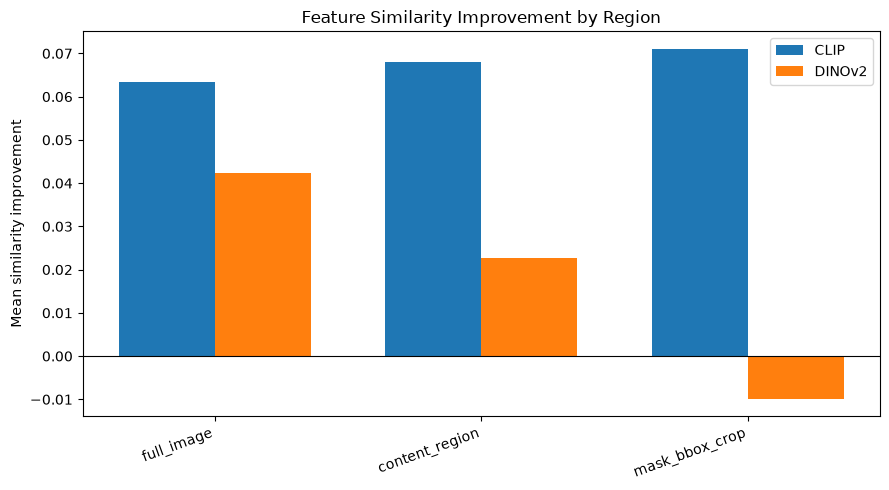

Saved figure: outputs/figures/opencv_feature_similarity/feature_similarity_improvement_by_region.png


In [28]:
# Figure 1: mean feature improvement by evaluation region

region_plot_df = (
    feature_summary_tables["by_region"]
    .sort_values(
        "mean_dinov2_similarity_improvement",
        ascending=False,
    )
    .copy()
)

x_positions = np.arange(
    len(region_plot_df)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    x_positions - bar_width / 2,
    region_plot_df["mean_clip_similarity_improvement"],
    width=bar_width,
    label="CLIP",
)

ax.bar(
    x_positions + bar_width / 2,
    region_plot_df["mean_dinov2_similarity_improvement"],
    width=bar_width,
    label="DINOv2",
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    region_plot_df["evaluation_region"],
    rotation=20,
    ha="right",
)

ax.set_ylabel(
    "Mean similarity improvement"
)

ax.set_title(
    "Feature Similarity Improvement by Region"
)

ax.legend()

region_improvement_figure_path = save_current_figure(
    "feature_similarity_improvement_by_region.png"
)

print(
    "Saved figure:",
    region_improvement_figure_path.relative_to(PROJECT_ROOT).as_posix(),
)

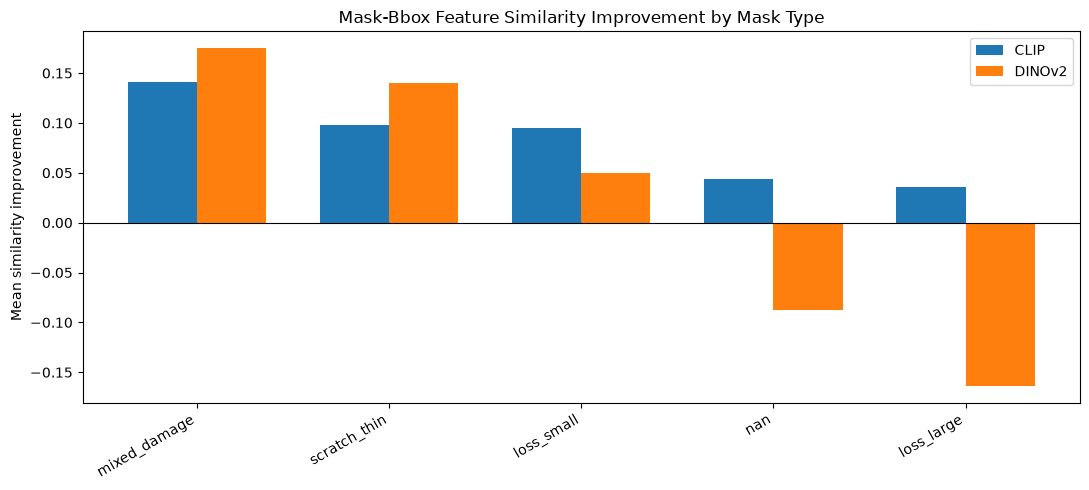

Saved figure: outputs/figures/opencv_feature_similarity/feature_similarity_improvement_by_mask_type.png


,metric_mask_type,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
2,mixed_damage,50,50,0.831153,0.983684,0.142236,0.835676,0.977178,0.141503,1.000000,0.796848,0.946225,0.127705,0.741932,0.916844,0.174913,0.960000,0.158208,589824.0
3,scratch_thin,50,50,0.908363,0.999688,0.091445,0.901497,0.999472,0.097975,1.000000,0.886714,0.998889,0.111131,0.858221,0.998519,0.140298,1.000000,0.119136,589824.0
1,loss_small,50,50,0.894268,0.994536,0.096812,0.895158,0.989678,0.094521,1.000000,0.941226,0.978841,0.034467,0.920278,0.969906,0.049629,0.940000,0.072075,360000.0
4,nan,155,155,0.883358,0.933159,0.060046,0.866239,0.909712,0.043473,0.670968,0.923709,0.883107,-0.012773,0.887607,0.800146,-0.087460,0.367742,-0.021994,214369.0
0,loss_large,50,50,0.745157,0.786692,0.029322,0.750119,0.785892,0.035774,0.780000,0.727197,0.549102,-0.177261,0.708387,0.544456,-0.163931,0.160000,-0.064079,109561.0


In [29]:
# Figure 2: mask-bbox improvement by mask type

mask_bbox_df = feature_ok_df.loc[
    feature_ok_df["evaluation_region"].eq("mask_bbox_crop")
].copy()

if mask_bbox_df.empty:
    print(
        "No mask-bbox rows available; skipping mask-type feature plot."
    )
else:
    mask_type_plot_df = (
        summarize_feature_similarity_metrics(
            mask_bbox_df,
            group_columns=[
                "metric_mask_type",
            ],
        )
        .sort_values(
            "mean_dinov2_similarity_improvement",
            ascending=False,
        )
        .copy()
    )
    
    x_positions = np.arange(
        len(mask_type_plot_df)
    )
    
    fig, ax = plt.subplots(
        figsize=(11, 5)
    )
    
    ax.bar(
        x_positions - bar_width / 2,
        mask_type_plot_df["mean_clip_similarity_improvement"],
        width=bar_width,
        label="CLIP",
    )
    
    ax.bar(
        x_positions + bar_width / 2,
        mask_type_plot_df["mean_dinov2_similarity_improvement"],
        width=bar_width,
        label="DINOv2",
    )
    
    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
    )
    
    ax.set_xticks(
        x_positions
    )
    
    ax.set_xticklabels(
        mask_type_plot_df["metric_mask_type"],
        rotation=30,
        ha="right",
    )
    
    ax.set_ylabel(
        "Mean similarity improvement"
    )
    
    ax.set_title(
        "Mask-Bbox Feature Similarity Improvement by Mask Type"
    )
    
    ax.legend()
    
    mask_type_figure_path = save_current_figure(
        "feature_similarity_improvement_by_mask_type.png"
    )
    
    print(
        "Saved figure:",
        mask_type_figure_path.relative_to(PROJECT_ROOT).as_posix(),
    )
    
    display(
        mask_type_plot_df
    )

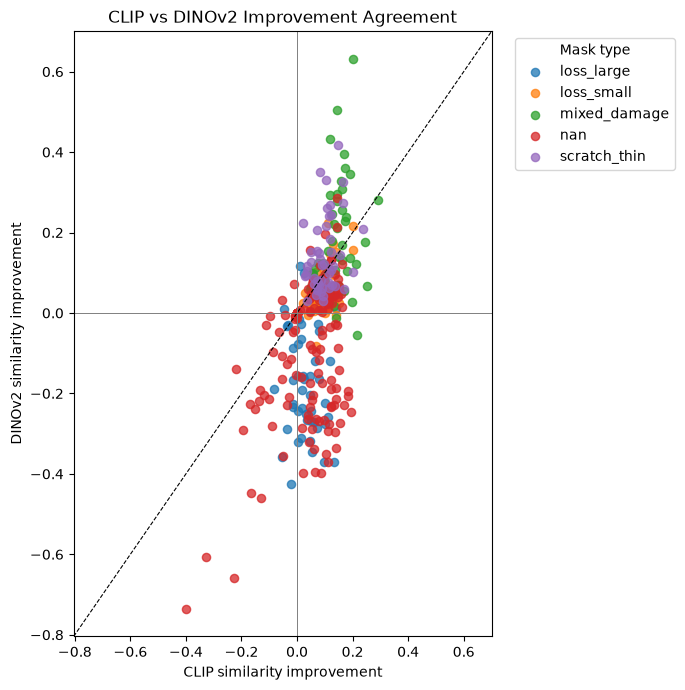

Saved figure: outputs/figures/opencv_feature_similarity/clip_vs_dinov2_feature_improvement_mask_bbox.png


In [30]:
# Figure 3: CLIP vs DINOv2 improvement agreement

scatter_df = mask_bbox_df.copy()

if scatter_df.empty:
    print(
        "No mask-bbox rows available; skipping CLIP-vs-DINOv2 scatter."
    )
else:
    fig, ax = plt.subplots(
        figsize=(7, 7)
    )
    
    for mask_type, subset_df in scatter_df.groupby(
        "metric_mask_type",
        dropna=False,
        sort=True,
    ):
        ax.scatter(
            subset_df["clip_similarity_improvement"],
            subset_df["dinov2_similarity_improvement"],
            s=35,
            alpha=0.75,
            label=str(mask_type),
        )
    
    min_axis_value = float(
        np.nanmin(
            [
                scatter_df["clip_similarity_improvement"].min(),
                scatter_df["dinov2_similarity_improvement"].min(),
                0,
            ]
        )
    )
    
    max_axis_value = float(
        np.nanmax(
            [
                scatter_df["clip_similarity_improvement"].max(),
                scatter_df["dinov2_similarity_improvement"].max(),
                0,
            ]
        )
    )
    
    axis_padding = max(
        0.01,
        (max_axis_value - min_axis_value) * 0.05,
    )
    
    ax.plot(
        [
            min_axis_value - axis_padding,
            max_axis_value + axis_padding,
        ],
        [
            min_axis_value - axis_padding,
            max_axis_value + axis_padding,
        ],
        color="black",
        linewidth=0.8,
        linestyle="--",
    )
    
    ax.axhline(
        0,
        color="grey",
        linewidth=0.7,
    )
    
    ax.axvline(
        0,
        color="grey",
        linewidth=0.7,
    )
    
    ax.set_xlim(
        min_axis_value - axis_padding,
        max_axis_value + axis_padding,
    )
    
    ax.set_ylim(
        min_axis_value - axis_padding,
        max_axis_value + axis_padding,
    )
    
    ax.set_xlabel(
        "CLIP similarity improvement"
    )
    
    ax.set_ylabel(
        "DINOv2 similarity improvement"
    )
    
    ax.set_title(
        "CLIP vs DINOv2 Improvement Agreement"
    )
    
    ax.legend(
        title="Mask type",
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
    )
    
    agreement_figure_path = save_current_figure(
        "clip_vs_dinov2_feature_improvement_mask_bbox.png"
    )
    
    print(
        "Saved figure:",
        agreement_figure_path.relative_to(PROJECT_ROOT).as_posix(),
    )

In [31]:
# Display figure inventory, without creating extra CSV outputs

feature_figure_inventory_df = pd.DataFrame(
    [
        {
            "figure_name": figure_path.name,
            "figure_path": figure_path.relative_to(PROJECT_ROOT).as_posix(),
            "file_size_bytes": figure_path.stat().st_size,
            "sha256": file_sha256(figure_path),
        }
        for figure_path in feature_figure_paths
    ]
)

display(
    feature_figure_inventory_df
)

print(
    "Notebook 12 display diagnostics complete."
)

,figure_name,figure_path,file_size_bytes,sha256
0,feature_similarity_improvement_by_region.png,outputs/figures/opencv_feature_similarity/feat...,59968,4d46449a8a71a263ac16dea33fb714f09baf3dbf6737d8...
1,feature_similarity_improvement_by_mask_type.png,outputs/figures/opencv_feature_similarity/feat...,70877,47ff0e66813b49c41989f4e848d92f292d181c3615e0bf...
2,clip_vs_dinov2_feature_improvement_mask_bbox.png,outputs/figures/opencv_feature_similarity/clip...,181958,ad9e408410a2f0fc8601cd16d5a7fa440eb22b270c18db...


Notebook 12 display diagnostics complete.


In [32]:
# Load optional prior metric outputs for display-only cross-metric comparison

optional_prior_metric_paths = {
    "lpips": LPIPS_METRICS_PATH,
    "classical": CLASSICAL_METRICS_PATH,
}

prior_metric_frames = {}

prior_metric_inventory_records = []

for metric_source, metric_path in optional_prior_metric_paths.items():
    metric_exists = metric_path.is_file()
    
    prior_metric_inventory_records.append(
        {
            "metric_source": metric_source,
            "path": metric_path.relative_to(PROJECT_ROOT).as_posix(),
            "exists": metric_exists,
            "file_size_bytes": metric_path.stat().st_size if metric_exists else 0,
        }
    )
    
    if metric_exists:
        prior_metric_frames[metric_source] = pd.read_csv(
            metric_path
        )

prior_metric_inventory_df = pd.DataFrame(
    prior_metric_inventory_records
)

display(
    prior_metric_inventory_df
)

if not prior_metric_frames:
    raise RuntimeError(
        "No LPIPS or classical metric CSVs found for Notebook 12 cross-metric comparison."
    )

for metric_source, metric_df in prior_metric_frames.items():
    print(
        f"\n{metric_source} columns:"
    )
    display(
        pd.DataFrame(
            {
                "column": metric_df.columns.tolist(),
            }
        )
    )

,metric_source,path,exists,file_size_bytes
0,lpips,data/processed/metrics/metrics_opencv_telea_lp...,True,845169
1,classical,data/processed/metrics/metrics_opencv_telea_cl...,True,1690289



lpips columns:


,column
0,lpips_row_id
1,lpips_case_id
2,metric_case_id
3,restoration_case_id
4,source_case_id
5,source_case_id_original
6,case_id
7,dataset_name
8,metric_applicability
9,painting_id



classical columns:


,column
0,metric_row_id
1,metric_case_id
2,restoration_case_id
3,source_case_id
4,source_case_id_original
5,case_id
6,dataset_name
7,metric_applicability
8,painting_id
9,category


In [33]:
# Helpers to standardize prior metric tables defensively

import re


def normalize_column_token(
    value: str,
) -> str:
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(value).strip().lower(),
    ).strip("_")


def contains_metric_token(
    column_name: str,
    metric_name: str,
) -> bool:
    normalized_column = normalize_column_token(
        column_name
    )
    
    normalized_metric = normalize_column_token(
        metric_name
    )
    
    return f"_{normalized_metric}_" in f"_{normalized_column}_"


def first_existing_column(
    dataframe: pd.DataFrame,
    candidates: list[str],
) -> str | None:
    for column in candidates:
        if column in dataframe.columns:
            return column
    
    return None


def normalize_evaluation_region_value(
    value: Any,
) -> str:
    region_text = str(value).strip().lower()
    
    region_map = {
        "full": "full_image",
        "full_image": "full_image",
        "image": "full_image",
        "content": "content_region",
        "content_region": "content_region",
        "content_box": "content_region",
        "mask": "mask_bbox_crop",
        "mask_bbox": "mask_bbox_crop",
        "mask_bbox_crop": "mask_bbox_crop",
        "bbox": "mask_bbox_crop",
        "crop": "mask_bbox_crop",
    }
    
    return region_map.get(
        region_text,
        region_text,
    )


case_key_lookup_df = restoration_metadata_df[
    [
        "metric_case_id",
        "restoration_case_id",
        "case_id",
        "dataset_name",
        "painting_id",
        "metric_mask_type",
    ]
].drop_duplicates().copy()

case_key_lookup_df = case_key_lookup_df.rename(
    columns={
        "metric_case_id": "feature_case_id",
    }
)

In [34]:
# Standardize case IDs, regions, and positive-better metric deltas

def attach_feature_case_id(
    metric_df: pd.DataFrame,
) -> pd.DataFrame:
    df = metric_df.copy()
    
    if "feature_case_id" in df.columns:
        df["feature_case_id"] = df["feature_case_id"].astype(str)
        return df
    
    if "metric_case_id" in df.columns:
        df["feature_case_id"] = df["metric_case_id"].astype(str)
        return df
    
    if "restoration_case_id" in df.columns:
        df = df.merge(
            case_key_lookup_df[
                [
                    "feature_case_id",
                    "restoration_case_id",
                ]
            ],
            on="restoration_case_id",
            how="left",
            validate="many_to_one",
        )
        return df
    
    if {"dataset_name", "case_id"}.issubset(df.columns):
        df = df.merge(
            case_key_lookup_df[
                [
                    "feature_case_id",
                    "dataset_name",
                    "case_id",
                ]
            ],
            on=[
                "dataset_name",
                "case_id",
            ],
            how="left",
            validate="many_to_one",
        )
        return df
    
    if "case_id" in df.columns:
        case_only_lookup_df = case_key_lookup_df[
            [
                "feature_case_id",
                "case_id",
            ]
        ].drop_duplicates()
        
        duplicated_case_ids = case_only_lookup_df["case_id"].duplicated(keep=False)
        
        unambiguous_case_only_lookup_df = case_only_lookup_df.loc[
            ~duplicated_case_ids
        ].copy()
        
        df = df.merge(
            unambiguous_case_only_lookup_df,
            on="case_id",
            how="left",
            validate="many_to_one",
        )
        return df
    
    df["feature_case_id"] = np.nan
    
    return df


def attach_evaluation_region(
    metric_df: pd.DataFrame,
) -> pd.DataFrame:
    df = metric_df.copy()
    
    if "evaluation_region" not in df.columns:
        region_column = first_existing_column(
            df,
            [
                "metric_region",
                "region",
                "region_name",
                "evaluation_area",
            ],
        )
        
        if region_column is None:
            df["evaluation_region"] = "unknown"
        else:
            df["evaluation_region"] = df[region_column]
    
    df["evaluation_region"] = df["evaluation_region"].map(
        normalize_evaluation_region_value
    )
    
    return df


def derive_positive_better_delta_columns(
    metric_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = metric_df.copy()
    
    numeric_columns = [
        column
        for column in df.columns
        if pd.api.types.is_numeric_dtype(df[column])
    ]
    
    metric_specs = [
        ("lpips", "lower"),
        ("mse", "lower"),
        ("rmse", "lower"),
        ("mae", "lower"),
        ("psnr", "higher"),
        ("ms_ssim", "higher"),
        ("ssim", "higher"),
    ]
    
    detection_records = []
    
    for metric_name, better_direction in metric_specs:
        metric_columns = [
            column
            for column in numeric_columns
            if contains_metric_token(column, metric_name)
        ]
        
        damaged_candidates = [
            column
            for column in metric_columns
            if any(
                token in normalize_column_token(column)
                for token in [
                    "damaged",
                    "degraded",
                    "corrupted",
                    "input",
                ]
            )
        ]
        
        restored_candidates = [
            column
            for column in metric_columns
            if any(
                token in normalize_column_token(column)
                for token in [
                    "restored",
                    "inpainted",
                    "output",
                ]
            )
        ]
        
        damaged_column = sorted(
            damaged_candidates,
            key=len,
        )[0] if damaged_candidates else None
        
        restored_column = sorted(
            restored_candidates,
            key=len,
        )[0] if restored_candidates else None
        
        output_column = f"{metric_name}_positive_better_delta"
        
        if damaged_column is not None and restored_column is not None:
            if better_direction == "higher":
                df[output_column] = (
                    df[restored_column] - df[damaged_column]
                )
            else:
                df[output_column] = (
                    df[damaged_column] - df[restored_column]
                )
            
            detection_status = "derived_from_damaged_and_restored"
        else:
            detection_status = "not_detected"
        
        detection_records.append(
            {
                "metric": metric_name,
                "better_direction": better_direction,
                "damaged_column": damaged_column,
                "restored_column": restored_column,
                "positive_better_delta_column": output_column if output_column in df.columns else None,
                "status": detection_status,
            }
        )
    
    return df, pd.DataFrame(
        detection_records
    )

In [35]:
# Build standardized prior metric frames

standardized_prior_frames = {}

prior_detection_tables = {}

for metric_source, metric_df in prior_metric_frames.items():
    standardized_df = attach_feature_case_id(
        metric_df
    )
    
    standardized_df = attach_evaluation_region(
        standardized_df
    )
    
    standardized_df, detection_df = derive_positive_better_delta_columns(
        standardized_df
    )
    
    standardized_prior_frames[metric_source] = standardized_df
    
    prior_detection_tables[metric_source] = detection_df
    
    print(
        f"\nDetected comparable {metric_source} metric deltas"
    )
    
    display(
        detection_df
    )
    
    display(
        pd.DataFrame(
            [
                {
                    "metric_source": metric_source,
                    "rows": len(standardized_df),
                    "mapped_feature_case_ids": int(standardized_df["feature_case_id"].notna().sum()),
                    "evaluation_regions": ", ".join(sorted(standardized_df["evaluation_region"].dropna().astype(str).unique())),
                }
            ]
        )
    )


Detected comparable lpips metric deltas


,metric,better_direction,damaged_column,restored_column,positive_better_delta_column,status
0,lpips,lower,damaged_lpips,restored_lpips,lpips_positive_better_delta,derived_from_damaged_and_restored
1,mse,lower,None,None,None,not_detected
2,rmse,lower,None,None,None,not_detected
3,mae,lower,None,None,None,not_detected
4,psnr,higher,None,None,None,not_detected
5,ms_ssim,higher,None,None,None,not_detected
6,ssim,higher,None,None,None,not_detected


,metric_source,rows,mapped_feature_case_ids,evaluation_regions
0,lpips,1175,1175,"content_region, full_image, mask_bbox_crop"



Detected comparable classical metric deltas


,metric,better_direction,damaged_column,restored_column,positive_better_delta_column,status
0,lpips,lower,None,None,None,not_detected
1,mse,lower,damaged_mse,restored_mse,mse_positive_better_delta,derived_from_damaged_and_restored
2,rmse,lower,None,None,None,not_detected
3,mae,lower,damaged_mae,restored_mae,mae_positive_better_delta,derived_from_damaged_and_restored
4,psnr,higher,damaged_psnr,restored_psnr,psnr_positive_better_delta,derived_from_damaged_and_restored
5,ms_ssim,higher,None,None,None,not_detected
6,ssim,higher,damaged_ssim,restored_ssim,ssim_positive_better_delta,derived_from_damaged_and_restored


,metric_source,rows,mapped_feature_case_ids,evaluation_regions
0,classical,2295,2295,"boundary_region, content_region, full_image, m..."


In [36]:
# Merge feature similarity with available LPIPS/classical positive-better deltas

feature_cross_base_df = feature_ok_df[
    [
        "feature_case_id",
        "dataset_name",
        "painting_id",
        "metric_mask_type",
        "evaluation_region",
        "clip_similarity_improvement",
        "dinov2_similarity_improvement",
        "mean_similarity_improvement",
    ]
].copy()

cross_metric_df = feature_cross_base_df.copy()

merged_prior_metric_columns = []

merge_coverage_records = []

for metric_source, standardized_df in standardized_prior_frames.items():
    prior_delta_columns = [
        column
        for column in standardized_df.columns
        if column.endswith("_positive_better_delta")
    ]
    
    if not prior_delta_columns:
        merge_coverage_records.append(
            {
                "metric_source": metric_source,
                "prior_delta_columns": "",
                "prior_rows": len(standardized_df),
                "matched_feature_rows": 0,
                "status": "no_comparable_delta_columns",
            }
        )
        continue
    
    renamed_delta_columns = {
        column: f"{metric_source}_{column}"
        for column in prior_delta_columns
    }
    
    prior_merge_df = standardized_df[
        [
            "feature_case_id",
            "evaluation_region",
            *prior_delta_columns,
        ]
    ].dropna(
        subset=[
            "feature_case_id",
            "evaluation_region",
        ]
    ).copy()
    
    prior_merge_df = (
        prior_merge_df
        .groupby(
            [
                "feature_case_id",
                "evaluation_region",
            ],
            as_index=False,
        )[prior_delta_columns]
        .mean()
        .rename(columns=renamed_delta_columns)
    )
    
    cross_metric_df = cross_metric_df.merge(
        prior_merge_df,
        on=[
            "feature_case_id",
            "evaluation_region",
        ],
        how="left",
        validate="one_to_one",
    )
    
    merged_columns = list(
        renamed_delta_columns.values()
    )
    
    merged_prior_metric_columns.extend(
        merged_columns
    )
    
    merge_coverage_records.append(
        {
            "metric_source": metric_source,
            "prior_delta_columns": ", ".join(merged_columns),
            "prior_rows": len(prior_merge_df),
            "matched_feature_rows": int(cross_metric_df[merged_columns].notna().any(axis=1).sum()),
            "status": "merged",
        }
    )

merge_coverage_df = pd.DataFrame(
    merge_coverage_records
)

display(
    merge_coverage_df
)

if not merged_prior_metric_columns:
    raise RuntimeError(
        "No comparable LPIPS/classical delta columns could be derived."
    )

,metric_source,prior_delta_columns,prior_rows,matched_feature_rows,status
0,lpips,lpips_lpips_positive_better_delta,1175,1175,merged
1,classical,"classical_mse_positive_better_delta, classical...",2295,1175,merged


In [37]:
# Correlation table: feature improvements vs LPIPS/classical improvements

feature_improvement_columns = [
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

correlation_records = []

for evaluation_region in [
    "all_regions",
    *sorted(cross_metric_df["evaluation_region"].dropna().astype(str).unique()),
]:
    if evaluation_region == "all_regions":
        region_df = cross_metric_df.copy()
    else:
        region_df = cross_metric_df.loc[
            cross_metric_df["evaluation_region"].astype(str).eq(evaluation_region)
        ].copy()
    
    for prior_metric_column in merged_prior_metric_columns:
        for feature_metric_column in feature_improvement_columns:
            valid_df = region_df[
                [
                    prior_metric_column,
                    feature_metric_column,
                ]
            ].dropna()
            
            if len(valid_df) < 3:
                pearson_corr = np.nan
                spearman_corr = np.nan
            else:
                pearson_corr = valid_df[prior_metric_column].corr(
                    valid_df[feature_metric_column],
                    method="pearson",
                )
                
                spearman_corr = valid_df[prior_metric_column].corr(
                    valid_df[feature_metric_column],
                    method="spearman",
                )
            
            correlation_records.append(
                {
                    "evaluation_region": evaluation_region,
                    "prior_metric": prior_metric_column,
                    "feature_metric": feature_metric_column,
                    "paired_rows": len(valid_df),
                    "pearson_corr": pearson_corr,
                    "spearman_corr": spearman_corr,
                }
            )

cross_metric_correlation_df = pd.DataFrame(
    correlation_records
).sort_values(
    [
        "evaluation_region",
        "prior_metric",
        "feature_metric",
    ]
)

display(
    cross_metric_correlation_df.round(4)
)

,evaluation_region,prior_metric,feature_metric,paired_rows,pearson_corr,spearman_corr
6,all_regions,classical_mae_positive_better_delta,clip_similarity_improvement,1175,-0.1446,-0.3105
7,all_regions,classical_mae_positive_better_delta,dinov2_similarity_improvement,1175,0.1081,-0.0153
8,all_regions,classical_mae_positive_better_delta,mean_similarity_improvement,1175,0.0239,-0.0971
3,all_regions,classical_mse_positive_better_delta,clip_similarity_improvement,1175,0.2280,0.4631
4,all_regions,classical_mse_positive_better_delta,dinov2_similarity_improvement,1175,-0.1795,0.0154
5,all_regions,classical_mse_positive_better_delta,mean_similarity_improvement,1175,-0.0443,0.1466
9,all_regions,classical_psnr_positive_better_delta,clip_similarity_improvement,1075,0.3834,0.5205
10,all_regions,classical_psnr_positive_better_delta,dinov2_similarity_improvement,1075,0.2383,0.5773
11,all_regions,classical_psnr_positive_better_delta,mean_similarity_improvement,1075,0.3179,0.6118
12,all_regions,classical_ssim_positive_better_delta,clip_similarity_improvement,1175,0.5179,0.6011


In [39]:
# Direction-agreement table using mean feature improvement

def improvement_direction(
    value: Any,
    tolerance: float = 1e-9,
) -> str:
    if pd.isna(value):
        return "missing"
    
    if value > tolerance:
        return "improved"
    
    if value < -tolerance:
        return "worse"
    
    return "flat"


agreement_records = []

for prior_metric_column in merged_prior_metric_columns:
    agreement_df = cross_metric_df[
        [
            "evaluation_region",
            "mean_similarity_improvement",
            prior_metric_column,
        ]
    ].dropna().copy()
    
    agreement_df["feature_direction"] = agreement_df["mean_similarity_improvement"].map(
        improvement_direction
    )
    
    agreement_df["prior_metric_direction"] = agreement_df[prior_metric_column].map(
        improvement_direction
    )
    
    agreement_df["directions_agree"] = (
        agreement_df["feature_direction"].eq(agreement_df["prior_metric_direction"])
    )
    
    for evaluation_region, region_df in agreement_df.groupby(
        "evaluation_region",
        dropna=False,
        sort=True,
    ):
        agreement_records.append(
            {
                "prior_metric": prior_metric_column,
                "evaluation_region": evaluation_region,
                "paired_rows": len(region_df),
                "agreement_rows": int(region_df["directions_agree"].sum()),
                "agreement_rate": float(region_df["directions_agree"].mean()) if len(region_df) else np.nan,
                "feature_improved_prior_worse": int(
                    (
                        region_df["feature_direction"].eq("improved")
                        & region_df["prior_metric_direction"].eq("worse")
                    ).sum()
                ),
                "feature_worse_prior_improved": int(
                    (
                        region_df["feature_direction"].eq("worse")
                        & region_df["prior_metric_direction"].eq("improved")
                    ).sum()
                ),
            }
        )

direction_agreement_df = pd.DataFrame(
    agreement_records
).sort_values(
    [
        "prior_metric",
        "evaluation_region",
    ]
)

display(
    direction_agreement_df.round(4)
)

,prior_metric,evaluation_region,paired_rows,agreement_rows,agreement_rate,feature_improved_prior_worse,feature_worse_prior_improved
6,classical_mae_positive_better_delta,content_region,410,154,0.3756,227,29
7,classical_mae_positive_better_delta,full_image,410,157,0.3829,224,29
8,classical_mae_positive_better_delta,mask_bbox_crop,355,131,0.3690,186,38
3,classical_mse_positive_better_delta,content_region,410,368,0.8976,0,42
4,classical_mse_positive_better_delta,full_image,410,363,0.8854,1,46
5,classical_mse_positive_better_delta,mask_bbox_crop,355,263,0.7408,0,92
9,classical_psnr_positive_better_delta,content_region,360,318,0.8833,0,42
10,classical_psnr_positive_better_delta,full_image,360,313,0.8694,1,46
11,classical_psnr_positive_better_delta,mask_bbox_crop,355,263,0.7408,0,92
12,classical_ssim_positive_better_delta,content_region,410,371,0.9049,0,39


In [40]:
# Show the most interesting disagreements, display-only

disagreement_display_columns = [
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "metric_mask_type",
    "evaluation_region",
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

for prior_metric_column in merged_prior_metric_columns:
    disagreement_df = cross_metric_df.dropna(
        subset=[
            "mean_similarity_improvement",
            prior_metric_column,
        ]
    ).copy()
    
    disagreement_df["feature_direction"] = disagreement_df["mean_similarity_improvement"].map(
        improvement_direction
    )
    
    disagreement_df["prior_metric_direction"] = disagreement_df[prior_metric_column].map(
        improvement_direction
    )
    
    disagreement_df = disagreement_df.loc[
        disagreement_df["feature_direction"].ne(disagreement_df["prior_metric_direction"])
    ].copy()
    
    if disagreement_df.empty:
        print(
            f"No direction disagreements for {prior_metric_column}."
        )
        continue
    
    disagreement_df["absolute_direction_gap"] = (
        disagreement_df["mean_similarity_improvement"].abs()
        + disagreement_df[prior_metric_column].abs()
    )
    
    print(
        f"\nLargest direction disagreements for {prior_metric_column}"
    )
    
    display(
        disagreement_df.sort_values(
            "absolute_direction_gap",
            ascending=False,
        )[
            [
                *disagreement_display_columns,
                prior_metric_column,
                "feature_direction",
                "prior_metric_direction",
            ]
        ].head(15).round(6)
    )


Largest direction disagreements for lpips_lpips_positive_better_delta


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_similarity_improvement,dinov2_similarity_improvement,mean_similarity_improvement,lpips_lpips_positive_better_delta,feature_direction,prior_metric_direction
819,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,0.014078,-0.159786,-0.072854,0.386641,worse,improved
142,opencv_telea__canonical__canonical__p011_loss_...,canonical,p011,loss_large,mask_bbox_crop,0.021194,-0.155758,-0.067282,0.382483,worse,improved
711,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.056702,-0.204001,-0.073649,0.359791,worse,improved
795,opencv_telea__damage_size__damage_size__p043__...,damage_size,p043,nan,mask_bbox_crop,-0.050836,-0.356166,-0.203501,0.224445,worse,improved
2,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,mask_bbox_crop,-0.047131,0.010395,-0.018368,0.397514,worse,improved
240,opencv_telea__canonical__canonical__p018_loss_...,canonical,p018,loss_large,mask_bbox_crop,0.097873,-0.370315,-0.136221,0.275194,worse,improved
604,opencv_telea__canonical__canonical__p044_loss_...,canonical,p044,loss_large,mask_bbox_crop,0.017821,-0.236026,-0.109102,0.301308,worse,improved
762,opencv_telea__damage_size__damage_size__p026__...,damage_size,p026,nan,mask_bbox_crop,0.085050,-0.398110,-0.156530,0.248496,worse,improved
735,opencv_telea__damage_size__damage_size__p018__...,damage_size,p018,nan,mask_bbox_crop,0.103400,-0.351020,-0.123810,0.277185,worse,improved
714,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.082992,-0.090681,-0.003844,0.388659,worse,improved



Largest direction disagreements for classical_mse_positive_better_delta


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_similarity_improvement,dinov2_similarity_improvement,mean_similarity_improvement,classical_mse_positive_better_delta,feature_direction,prior_metric_direction
714,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.082992,-0.090681,-0.003844,37.871878,worse,improved
2,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,mask_bbox_crop,-0.047131,0.010395,-0.018368,37.684607,worse,improved
747,opencv_telea__damage_size__damage_size__p026__...,damage_size,p026,nan,mask_bbox_crop,0.123184,-0.165484,-0.021150,36.712126,worse,improved
711,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.056702,-0.204001,-0.073649,34.241657,worse,improved
705,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.182849,-0.193064,-0.005108,34.056730,worse,improved
720,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,-0.053532,0.032475,-0.010529,33.395484,worse,improved
819,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,0.014078,-0.159786,-0.072854,32.210804,worse,improved
268,opencv_telea__canonical__canonical__p020_loss_...,canonical,p020,loss_large,mask_bbox_crop,-0.014655,-0.086219,-0.050437,31.386322,worse,improved
810,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,-0.007178,-0.042118,-0.024648,28.611962,worse,improved
768,opencv_telea__damage_size__damage_size__p039__...,damage_size,p039,nan,mask_bbox_crop,0.122154,-0.232910,-0.055378,28.530935,worse,improved



Largest direction disagreements for classical_mae_positive_better_delta


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_similarity_improvement,dinov2_similarity_improvement,mean_similarity_improvement,classical_mae_positive_better_delta,feature_direction,prior_metric_direction
72,opencv_telea__canonical__canonical__p006_loss_...,canonical,p006,loss_large,mask_bbox_crop,0.135764,0.045303,0.090533,-79.562612,improved,worse
813,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,0.089659,0.068351,0.079005,-79.220494,improved,worse
717,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,-0.011329,0.072481,0.030576,-74.608152,improved,worse
807,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,0.160216,0.121252,0.140734,-71.269957,improved,worse
100,opencv_telea__canonical__canonical__p008_loss_...,canonical,p008,loss_large,mask_bbox_crop,0.073798,-0.026594,0.023602,-59.419093,improved,worse
816,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,0.119794,-0.034889,0.042453,-58.428124,improved,worse
1129,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p039,nan,mask_bbox_crop,-0.091763,-0.279800,-0.185782,53.772475,worse,improved
16,opencv_telea__canonical__canonical__p002_loss_...,canonical,p002,loss_large,mask_bbox_crop,0.064878,0.048561,0.056719,-53.660937,improved,worse
708,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.145374,-0.030871,0.057252,-45.596086,improved,worse
702,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.088158,0.086752,0.087455,-43.158033,improved,worse



Largest direction disagreements for classical_psnr_positive_better_delta


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_similarity_improvement,dinov2_similarity_improvement,mean_similarity_improvement,classical_psnr_positive_better_delta,feature_direction,prior_metric_direction
437,opencv_telea__canonical__canonical__p032_loss_...,canonical,p032,loss_small,full_image,0.018501,-0.097422,-0.039460,5.434980,worse,improved
438,opencv_telea__canonical__canonical__p032_loss_...,canonical,p032,loss_small,content_region,0.014576,-0.066383,-0.025904,5.434980,worse,improved
439,opencv_telea__canonical__canonical__p032_loss_...,canonical,p032,loss_small,mask_bbox_crop,0.068824,-0.081894,-0.006535,5.434980,worse,improved
492,opencv_telea__canonical__canonical__p036_loss_...,canonical,p036,loss_large,mask_bbox_crop,0.012827,-0.027974,-0.007573,4.808826,worse,improved
747,opencv_telea__damage_size__damage_size__p026__...,damage_size,p026,nan,mask_bbox_crop,0.123184,-0.165484,-0.021150,4.275251,worse,improved
714,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.082992,-0.090681,-0.003844,3.720585,worse,improved
2,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,mask_bbox_crop,-0.047131,0.010395,-0.018368,3.592504,worse,improved
0,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,full_image,0.003774,-0.039509,-0.017867,3.592504,worse,improved
1,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,content_region,0.013768,-0.035268,-0.010750,3.592504,worse,improved
705,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.182849,-0.193064,-0.005108,3.545018,worse,improved



Largest direction disagreements for classical_ssim_positive_better_delta


,feature_case_id,dataset_name,painting_id,metric_mask_type,evaluation_region,clip_similarity_improvement,dinov2_similarity_improvement,mean_similarity_improvement,classical_ssim_positive_better_delta,feature_direction,prior_metric_direction
711,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.056702,-0.204001,-0.073649,0.334974,worse,improved
795,opencv_telea__damage_size__damage_size__p043__...,damage_size,p043,nan,mask_bbox_crop,-0.050836,-0.356166,-0.203501,0.204007,worse,improved
819,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,0.014078,-0.159786,-0.072854,0.321921,worse,improved
2,opencv_telea__canonical__canonical__p001_loss_...,canonical,p001,loss_large,mask_bbox_crop,-0.047131,0.010395,-0.018368,0.365511,worse,improved
720,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,-0.053532,0.032475,-0.010529,0.348402,worse,improved
714,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.082992,-0.090681,-0.003844,0.351712,worse,improved
705,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,mask_bbox_crop,0.182849,-0.193064,-0.005108,0.350316,worse,improved
810,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,mask_bbox_crop,-0.007178,-0.042118,-0.024648,0.327669,worse,improved
792,opencv_telea__damage_size__damage_size__p043__...,damage_size,p043,nan,mask_bbox_crop,0.043413,-0.319863,-0.138225,0.205986,worse,improved
798,opencv_telea__damage_size__damage_size__p043__...,damage_size,p043,nan,mask_bbox_crop,0.016612,-0.284980,-0.134184,0.209672,worse,improved


In [41]:
# Compact interpretation notes for the notebook

strongest_alignment_df = (
    cross_metric_correlation_df
    .dropna(
        subset=[
            "spearman_corr",
        ]
    )
    .sort_values(
        "spearman_corr",
        ascending=False,
    )
    .head(10)
)

weakest_alignment_df = (
    cross_metric_correlation_df
    .dropna(
        subset=[
            "spearman_corr",
        ]
    )
    .sort_values(
        "spearman_corr",
        ascending=True,
    )
    .head(10)
)

print(
    "Strongest positive rank alignments"
)
display(
    strongest_alignment_df.round(4)
)

print(
    "Weakest or inverse rank alignments"
)
display(
    weakest_alignment_df.round(4)
)

print(
    "Notebook 12 cross-metric comparison complete. No additional CSV outputs were written."
)

Strongest positive rank alignments


,evaluation_region,prior_metric,feature_metric,paired_rows,pearson_corr,spearman_corr
17,content_region,lpips_lpips_positive_better_delta,mean_similarity_improvement,410,0.8098,0.8394
32,full_image,lpips_lpips_positive_better_delta,mean_similarity_improvement,410,0.7985,0.8267
30,full_image,lpips_lpips_positive_better_delta,clip_similarity_improvement,410,0.8068,0.8191
15,content_region,lpips_lpips_positive_better_delta,clip_similarity_improvement,410,0.7929,0.8077
0,all_regions,lpips_lpips_positive_better_delta,clip_similarity_improvement,1175,0.7830,0.7626
31,full_image,lpips_lpips_positive_better_delta,dinov2_similarity_improvement,410,0.6978,0.7461
16,content_region,lpips_lpips_positive_better_delta,dinov2_similarity_improvement,410,0.6876,0.7309
42,full_image,classical_ssim_positive_better_delta,clip_similarity_improvement,410,0.7488,0.7099
29,content_region,classical_ssim_positive_better_delta,mean_similarity_improvement,410,0.7276,0.7069
27,content_region,classical_ssim_positive_better_delta,clip_similarity_improvement,410,0.7448,0.7015


Weakest or inverse rank alignments


,evaluation_region,prior_metric,feature_metric,paired_rows,pearson_corr,spearman_corr
36,full_image,classical_mae_positive_better_delta,clip_similarity_improvement,410,-0.3286,-0.3730
21,content_region,classical_mae_positive_better_delta,clip_similarity_improvement,410,-0.3270,-0.3672
6,all_regions,classical_mae_positive_better_delta,clip_similarity_improvement,1175,-0.1446,-0.3105
49,mask_bbox_crop,classical_mse_positive_better_delta,dinov2_similarity_improvement,355,-0.2500,-0.3102
38,full_image,classical_mae_positive_better_delta,mean_similarity_improvement,410,-0.2277,-0.2264
23,content_region,classical_mae_positive_better_delta,mean_similarity_improvement,410,-0.2281,-0.2237
50,mask_bbox_crop,classical_mse_positive_better_delta,mean_similarity_improvement,355,-0.1138,-0.2106
51,mask_bbox_crop,classical_mae_positive_better_delta,clip_similarity_improvement,355,-0.0954,-0.1479
37,full_image,classical_mae_positive_better_delta,dinov2_similarity_improvement,410,-0.1461,-0.1324
22,content_region,classical_mae_positive_better_delta,dinov2_similarity_improvement,410,-0.1255,-0.1004


Notebook 12 cross-metric comparison complete. No additional CSV outputs were written.


In [42]:
# Final artifact inventory: canonical outputs + diagnostic figures only

from pathlib import Path
from IPython.display import Markdown, display


def project_relative_path(
    path: Path,
) -> str:
    path = Path(path)
    
    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


feature_metrics_disk_df = pd.read_csv(
    FEATURE_OUTPUT_PATH
)

feature_audit_disk_df = pd.read_csv(
    AUDIT_OUTPUT_PATH
)

if "feature_figure_paths" in globals():
    final_figure_paths = [
        Path(figure_path)
        for figure_path in feature_figure_paths
        if Path(figure_path).is_file()
    ]
else:
    final_figure_paths = sorted(
        FIGURE_DIR.glob("*.png")
    ) if FIGURE_DIR.is_dir() else []


final_artifact_records = [
    {
        "artifact_type": "canonical_metrics_csv",
        "artifact_name": FEATURE_OUTPUT_PATH.name,
        "artifact_path": project_relative_path(FEATURE_OUTPUT_PATH),
        "exists": FEATURE_OUTPUT_PATH.is_file(),
        "rows": len(feature_metrics_disk_df),
        "file_size_bytes": FEATURE_OUTPUT_PATH.stat().st_size,
        "sha256": file_sha256(FEATURE_OUTPUT_PATH),
    },
    {
        "artifact_type": "audit_csv",
        "artifact_name": AUDIT_OUTPUT_PATH.name,
        "artifact_path": project_relative_path(AUDIT_OUTPUT_PATH),
        "exists": AUDIT_OUTPUT_PATH.is_file(),
        "rows": len(feature_audit_disk_df),
        "file_size_bytes": AUDIT_OUTPUT_PATH.stat().st_size,
        "sha256": file_sha256(AUDIT_OUTPUT_PATH),
    },
]

for figure_path in final_figure_paths:
    final_artifact_records.append(
        {
            "artifact_type": "diagnostic_figure_png",
            "artifact_name": figure_path.name,
            "artifact_path": project_relative_path(figure_path),
            "exists": figure_path.is_file(),
            "rows": np.nan,
            "file_size_bytes": figure_path.stat().st_size,
            "sha256": file_sha256(figure_path),
        }
    )

final_artifact_inventory_df = pd.DataFrame(
    final_artifact_records
)

display(
    final_artifact_inventory_df
)

,artifact_type,artifact_name,artifact_path,exists,rows,file_size_bytes,sha256
0,canonical_metrics_csv,metrics_opencv_telea_feature_similarity.csv,data/processed/metrics/metrics_opencv_telea_fe...,True,1175.0,1407056,70a32457f3adb2ad59409b93ded14852a4f28508c0e7ee...
1,audit_csv,opencv_feature_similarity_audit.csv,outputs/12_opencv_feature_similarity/opencv_fe...,True,1.0,1272,d7cdbdb8a9eddd46a0f4766f4f84d831973f69d58fadef...
2,diagnostic_figure_png,feature_similarity_improvement_by_region.png,outputs/figures/opencv_feature_similarity/feat...,True,NaN,59968,4d46449a8a71a263ac16dea33fb714f09baf3dbf6737d8...
3,diagnostic_figure_png,feature_similarity_improvement_by_mask_type.png,outputs/figures/opencv_feature_similarity/feat...,True,NaN,70877,47ff0e66813b49c41989f4e848d92f292d181c3615e0bf...
4,diagnostic_figure_png,clip_vs_dinov2_feature_improvement_mask_bbox.png,outputs/figures/opencv_feature_similarity/clip...,True,NaN,181958,ad9e408410a2f0fc8601cd16d5a7fa440eb22b270c18db...


In [43]:
# Final schema and row-contract sanity checks

def final_check(
    check_name: str,
    actual: Any,
    expected: Any,
    passed: bool,
) -> dict:
    return {
        "check": check_name,
        "actual": actual,
        "expected": expected,
        "passed": bool(passed),
    }


required_feature_columns = [
    "feature_row_id",
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "metric_mask_type",
    "evaluation_region",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
    "status",
    "issue",
]

numeric_similarity_columns = [
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

missing_required_columns = [
    column
    for column in required_feature_columns
    if column not in feature_metrics_disk_df.columns
]

actual_region_counts = (
    feature_metrics_disk_df["evaluation_region"]
    .value_counts(dropna=False)
    .sort_index()
    .to_dict()
)

expected_region_counts_sorted = dict(
    sorted(
        expected_feature_region_counts.items()
    )
)

duplicate_feature_row_ids = int(
    feature_metrics_disk_df["feature_row_id"].duplicated().sum()
) if "feature_row_id" in feature_metrics_disk_df.columns else len(feature_metrics_disk_df)

duplicate_case_region_rows = int(
    feature_metrics_disk_df[
        [
            "feature_case_id",
            "evaluation_region",
        ]
    ].duplicated().sum()
) if {
    "feature_case_id",
    "evaluation_region",
}.issubset(feature_metrics_disk_df.columns) else len(feature_metrics_disk_df)

numeric_finite_check = True

for column in numeric_similarity_columns:
    if column not in feature_metrics_disk_df.columns:
        numeric_finite_check = False
        continue
    
    numeric_values = pd.to_numeric(
        feature_metrics_disk_df[column],
        errors="coerce",
    )
    
    numeric_finite_check = bool(
        numeric_finite_check
        and numeric_values.notna().all()
        and np.isfinite(numeric_values).all()
    )

final_schema_validation_df = pd.DataFrame(
    [
        final_check(
            "canonical_metrics_csv_exists",
            FEATURE_OUTPUT_PATH.is_file(),
            True,
            FEATURE_OUTPUT_PATH.is_file(),
        ),
        final_check(
            "audit_csv_exists",
            AUDIT_OUTPUT_PATH.is_file(),
            True,
            AUDIT_OUTPUT_PATH.is_file(),
        ),
        final_check(
            "canonical_metrics_row_count",
            len(feature_metrics_disk_df),
            expected_feature_rows,
            len(feature_metrics_disk_df) == expected_feature_rows,
        ),
        final_check(
            "required_columns_present",
            missing_required_columns,
            [],
            len(missing_required_columns) == 0,
        ),
        final_check(
            "region_counts_match_expected",
            actual_region_counts,
            expected_region_counts_sorted,
            actual_region_counts == expected_region_counts_sorted,
        ),
        final_check(
            "all_rows_successful",
            int(feature_metrics_disk_df["status"].astype(str).eq("ok").sum()),
            len(feature_metrics_disk_df),
            bool(feature_metrics_disk_df["status"].astype(str).eq("ok").all()),
        ),
        final_check(
            "feature_row_ids_unique",
            duplicate_feature_row_ids,
            0,
            duplicate_feature_row_ids == 0,
        ),
        final_check(
            "case_region_rows_unique",
            duplicate_case_region_rows,
            0,
            duplicate_case_region_rows == 0,
        ),
        final_check(
            "numeric_similarity_columns_finite",
            numeric_finite_check,
            True,
            numeric_finite_check,
        ),
        final_check(
            "audit_has_one_row",
            len(feature_audit_disk_df),
            1,
            len(feature_audit_disk_df) == 1,
        ),
    ]
)

display(
    final_schema_validation_df
)

if not final_schema_validation_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 12 final schema validation failed."
    )

print(
    "Notebook 12 final schema validation passed."
)

,check,actual,expected,passed
0,canonical_metrics_csv_exists,True,True,True
1,audit_csv_exists,True,True,True
2,canonical_metrics_row_count,1175,1175,True
3,required_columns_present,[],[],True
4,region_counts_match_expected,"{'content_region': 410, 'full_image': 410, 'ma...","{'content_region': 410, 'full_image': 410, 'ma...",True
5,all_rows_successful,1175,1175,True
6,feature_row_ids_unique,0,0,True
7,case_region_rows_unique,0,0,True
8,numeric_similarity_columns_finite,True,True,True
9,audit_has_one_row,1,1,True


Notebook 12 final schema validation passed.


In [44]:
# Downstream dashboard/report readiness checks

metadata_case_ids = set(
    restoration_metadata_df["metric_case_id"].astype(str)
)

feature_case_ids = set(
    feature_metrics_disk_df["feature_case_id"].astype(str)
)

unknown_feature_case_ids = sorted(
    feature_case_ids - metadata_case_ids
)

missing_feature_case_ids = sorted(
    metadata_case_ids - feature_case_ids
)

dashboard_required_columns = [
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "metric_mask_type",
    "evaluation_region",
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

missing_dashboard_columns = [
    column
    for column in dashboard_required_columns
    if column not in feature_metrics_disk_df.columns
]

final_readiness_df = pd.DataFrame(
    [
        final_check(
            "dashboard_columns_present",
            missing_dashboard_columns,
            [],
            len(missing_dashboard_columns) == 0,
        ),
        final_check(
            "all_metadata_cases_represented",
            len(missing_feature_case_ids),
            0,
            len(missing_feature_case_ids) == 0,
        ),
        final_check(
            "no_unknown_feature_cases",
            len(unknown_feature_case_ids),
            0,
            len(unknown_feature_case_ids) == 0,
        ),
        final_check(
            "has_feature_figures",
            len(final_figure_paths),
            ">= 1",
            len(final_figure_paths) >= 1,
        ),
        final_check(
            "cross_metric_correlation_available",
            "cross_metric_correlation_df" in globals(),
            True,
            "cross_metric_correlation_df" in globals(),
        ),
        final_check(
            "direction_agreement_available",
            "direction_agreement_df" in globals(),
            True,
            "direction_agreement_df" in globals(),
        ),
    ]
)

display(
    final_readiness_df
)

if not final_readiness_df["passed"].astype(bool).all():
    raise RuntimeError(
        "Notebook 12 downstream readiness validation failed."
    )

print(
    "Notebook 12 is ready for downstream dashboard/report use."
)

,check,actual,expected,passed
0,dashboard_columns_present,[],[],True
1,all_metadata_cases_represented,0,0,True
2,no_unknown_feature_cases,0,0,True
3,has_feature_figures,3,>= 1,True
4,cross_metric_correlation_available,True,True,True
5,direction_agreement_available,True,True,True


Notebook 12 is ready for downstream dashboard/report use.


In [45]:
# Final display summaries and short written findings

final_feature_ok_df = feature_metrics_disk_df.loc[
    feature_metrics_disk_df["status"].astype(str).eq("ok")
].copy()

final_region_summary_df = summarize_feature_similarity_metrics(
    final_feature_ok_df,
    group_columns=[
        "evaluation_region",
    ],
)

final_mask_bbox_df = final_feature_ok_df.loc[
    final_feature_ok_df["evaluation_region"].eq("mask_bbox_crop")
].copy()

if final_mask_bbox_df.empty:
    final_mask_type_summary_df = pd.DataFrame()
else:
    final_mask_type_summary_df = summarize_feature_similarity_metrics(
        final_mask_bbox_df,
        group_columns=[
            "metric_mask_type",
        ],
    )

display(
    final_region_summary_df
)

if not final_mask_type_summary_df.empty:
    display(
        final_mask_type_summary_df
    )


def signed_float(
    value: Any,
    digits: int = 4,
) -> str:
    if pd.isna(value):
        return "n/a"
    
    return f"{float(value):+.{digits}f}"


best_region_row = final_region_summary_df.sort_values(
    "mean_dinov2_similarity_improvement",
    ascending=False,
).iloc[0]

weakest_region_row = final_region_summary_df.sort_values(
    "mean_dinov2_similarity_improvement",
    ascending=True,
).iloc[0]

finding_lines = [
    f"- Canonical feature-similarity output contains `{len(feature_metrics_disk_df)}` rows across `{restoration_metadata_df['metric_case_id'].nunique()}` restoration cases.",
    f"- Best DINOv2 region-level mean improvement: `{best_region_row['evaluation_region']}` at `{signed_float(best_region_row['mean_dinov2_similarity_improvement'])}`.",
    f"- Weakest DINOv2 region-level mean improvement: `{weakest_region_row['evaluation_region']}` at `{signed_float(weakest_region_row['mean_dinov2_similarity_improvement'])}`.",
]

if not final_mask_type_summary_df.empty:
    best_mask_row = final_mask_type_summary_df.sort_values(
        "mean_dinov2_similarity_improvement",
        ascending=False,
    ).iloc[0]
    
    weakest_mask_row = final_mask_type_summary_df.sort_values(
        "mean_dinov2_similarity_improvement",
        ascending=True,
    ).iloc[0]
    
    finding_lines.extend(
        [
            f"- Best mask-bbox mask type by DINOv2 mean improvement: `{best_mask_row['metric_mask_type']}` at `{signed_float(best_mask_row['mean_dinov2_similarity_improvement'])}`.",
            f"- Weakest mask-bbox mask type by DINOv2 mean improvement: `{weakest_mask_row['metric_mask_type']}` at `{signed_float(weakest_mask_row['mean_dinov2_similarity_improvement'])}`.",
        ]
    )

if "cross_metric_correlation_df" in globals():
    valid_correlation_df = cross_metric_correlation_df.dropna(
        subset=[
            "spearman_corr",
        ]
    ).copy()
    
    if not valid_correlation_df.empty:
        strongest_corr_row = valid_correlation_df.sort_values(
            "spearman_corr",
            ascending=False,
        ).iloc[0]
        
        weakest_corr_row = valid_correlation_df.sort_values(
            "spearman_corr",
            ascending=True,
        ).iloc[0]
        
        finding_lines.extend(
            [
                f"- Strongest cross-metric rank alignment: `{strongest_corr_row['feature_metric']}` vs `{strongest_corr_row['prior_metric']}` in `{strongest_corr_row['evaluation_region']}` with Spearman `{signed_float(strongest_corr_row['spearman_corr'])}`.",
                f"- Weakest/inverse cross-metric rank alignment: `{weakest_corr_row['feature_metric']}` vs `{weakest_corr_row['prior_metric']}` in `{weakest_corr_row['evaluation_region']}` with Spearman `{signed_float(weakest_corr_row['spearman_corr'])}`.",
            ]
        )

if "direction_agreement_df" in globals() and not direction_agreement_df.empty:
    valid_agreement_df = direction_agreement_df.loc[
        direction_agreement_df["paired_rows"].gt(0)
    ].copy()
    
    if not valid_agreement_df.empty:
        best_agreement_row = valid_agreement_df.sort_values(
            "agreement_rate",
            ascending=False,
        ).iloc[0]
        
        finding_lines.append(
            f"- Highest direction agreement: `{best_agreement_row['prior_metric']}` in `{best_agreement_row['evaluation_region']}` at `{best_agreement_row['agreement_rate']:.2%}` over `{int(best_agreement_row['paired_rows'])}` paired rows."
        )

display(
    Markdown(
        "### Notebook 12 Final Findings\n"
        + "\n".join(finding_lines)
    )
)

,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,full_image,410,410,0.908586,0.996138,0.067695,0.910832,0.974196,0.063363,0.739024,0.932233,0.985356,0.018629,0.893169,0.935465,0.042296,0.573171,0.052830,589824.0
1,content_region,410,410,0.893537,0.995892,0.074838,0.899581,0.967515,0.067933,0.748780,0.940489,0.985850,0.008978,0.911146,0.933796,0.022650,0.548780,0.045292,440064.0
2,mask_bbox_crop,355,355,0.871298,0.983821,0.081086,0.854618,0.925680,0.071062,0.825352,0.876671,0.960650,0.025808,0.842310,0.832420,-0.009890,0.591549,0.030586,376996.0


,metric_mask_type,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,loss_large,50,50,0.745157,0.786692,0.029322,0.750119,0.785892,0.035774,0.780000,0.727197,0.549102,-0.177261,0.708387,0.544456,-0.163931,0.160000,-0.064079,109561.0
1,loss_small,50,50,0.894268,0.994536,0.096812,0.895158,0.989678,0.094521,1.000000,0.941226,0.978841,0.034467,0.920278,0.969906,0.049629,0.940000,0.072075,360000.0
2,mixed_damage,50,50,0.831153,0.983684,0.142236,0.835676,0.977178,0.141503,1.000000,0.796848,0.946225,0.127705,0.741932,0.916844,0.174913,0.960000,0.158208,589824.0
3,scratch_thin,50,50,0.908363,0.999688,0.091445,0.901497,0.999472,0.097975,1.000000,0.886714,0.998889,0.111131,0.858221,0.998519,0.140298,1.000000,0.119136,589824.0
4,NaN,155,155,0.883358,0.933159,0.060046,0.866239,0.909712,0.043473,0.670968,0.923709,0.883107,-0.012773,0.887607,0.800146,-0.087460,0.367742,-0.021994,214369.0


### Notebook 12 Final Findings
- Canonical feature-similarity output contains `1175` rows across `410` restoration cases.
- Best DINOv2 region-level mean improvement: `full_image` at `+0.0423`.
- Weakest DINOv2 region-level mean improvement: `mask_bbox_crop` at `-0.0099`.
- Best mask-bbox mask type by DINOv2 mean improvement: `mixed_damage` at `+0.1749`.
- Weakest mask-bbox mask type by DINOv2 mean improvement: `loss_large` at `-0.1639`.
- Strongest cross-metric rank alignment: `mean_similarity_improvement` vs `lpips_lpips_positive_better_delta` in `content_region` with Spearman `+0.8394`.
- Weakest/inverse cross-metric rank alignment: `clip_similarity_improvement` vs `classical_mae_positive_better_delta` in `full_image` with Spearman `-0.3730`.
- Highest direction agreement: `classical_ssim_positive_better_delta` in `content_region` at `90.49%` over `410` paired rows.

In [46]:
# Final closure marker

notebook_12_closure_df = pd.DataFrame(
    [
        {
            "notebook": NOTEBOOK_NAME,
            "model_name": MODEL_NAME,
            "canonical_metrics_path": project_relative_path(FEATURE_OUTPUT_PATH),
            "audit_path": project_relative_path(AUDIT_OUTPUT_PATH),
            "canonical_rows": len(feature_metrics_disk_df),
            "validation_status": "passed",
            "downstream_status": "ready",
            "extra_metric_csvs_written_in_final_batches": 0,
        }
    ]
)

display(
    notebook_12_closure_df
)

print(
    "Notebook 12 complete: feature-similarity metrics are validated, interpreted, and ready for dashboard/report integration."
)

,notebook,model_name,canonical_metrics_path,audit_path,canonical_rows,validation_status,downstream_status,extra_metric_csvs_written_in_final_batches
0,12_opencv_feature_similarity,opencv_telea,data/processed/metrics/metrics_opencv_telea_fe...,outputs/12_opencv_feature_similarity/opencv_fe...,1175,passed,ready,0


Notebook 12 complete: feature-similarity metrics are validated, interpreted, and ready for dashboard/report integration.
